# Mini-Project 2 — Stock Price Prediction: LSTM vs Ridge

V prvom mini-projekte sme použili klasické regresné modely na predikciu cien NASDAQ-100,
ale išli sme trochu nesprávnym smerom a použili sme iné metriky. V mini-projekte 2 sme
opravili svoje počiatočné chyby — trénovali sme regresné modely na menšej vzorke dát
a použili sme iné techniky ako deep learning (LSTM). Taktiež sme vyskúšali aj
Transformer s fine-tuningom (Chronos od Amazonu), čo vôbec nedalo ani porovnateľne
dobré výsledky s regresiou alebo LSTM. Viac informácií v závere.

Hlavnou úlohou tohto projektu bolo zistiť, **či deep learning skutočne pomôže pri
predikcii cien akcií**.

### Otázka

> **Dokáže LSTM prekonať Ridge pri predikcii cien NASDAQ-100 akcií?**

### Dataset

NASDAQ-100 Historical Data (2000–2026), ~514 000 riadkov, ~100 tickerov.
Stĺpce: Ticker, Date, Open, High, Low, Close, Adj Close, Volume.

### Metriky: R², RMSE, MAE


# EDA — NASDAQ-100 Historical Data

*(prevzatá z MP1, rovnaký dataset)*


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
import warnings

warnings.filterwarnings('ignore')

# Plot style ---
sns.set_theme(style='whitegrid', palette='tab10')
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'figure.titlesize': 15,
})

In [ ]:
df = pd.read_csv('/content/NASDAQ100_Historical_Data.csv', parse_dates=['Date'])
df = df.sort_values(['Ticker', 'Date']).reset_index(drop=True)

TICKERS = df['Ticker'].unique().tolist()

SAMPLE_TICKERS = ['AAPL', 'MSFT', 'AMZN', 'NVDA', 'META']
SAMPLE_TICKERS = [t for t in SAMPLE_TICKERS if t in TICKERS]

## Základný prehľad datasetu


In [ ]:
print('=== Basic info ===')
print(f'Rows       : {len(df):,}')
print(f'Columns    : {df.columns.tolist()}')
print(f'Tickers    : {len(TICKERS)}')
print(f'Date range : {df["Date"].min().date()} → {df["Date"].max().date()}')
print()
df.dtypes

=== Basic info ===
Rows       : 514,075
Columns    : ['Ticker', 'Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']
Tickers    : 100
Date range : 2000-01-03 → 2026-02-18



,0
Ticker,object
Date,datetime64[ns]
Open,float64
High,float64
Low,float64
Close,float64
Adj Close,float64
Volume,int64


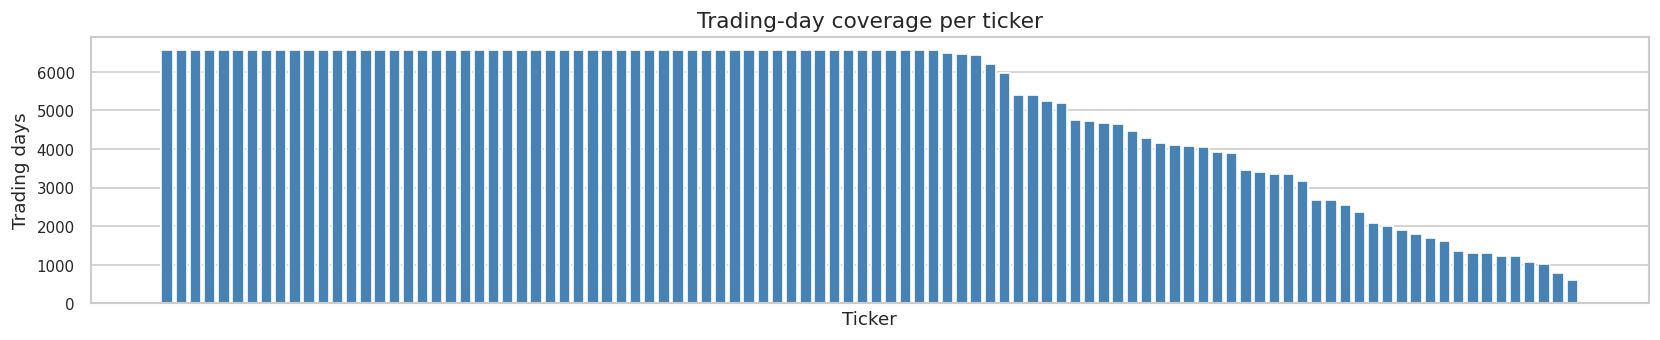

Min coverage: 609 | Max coverage: 6571


In [ ]:
rows_per_ticker = df.groupby('Ticker').size().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 3))
ax.bar(rows_per_ticker.index, rows_per_ticker.values, width=0.8, color='steelblue')
ax.set_xlabel('Ticker')
ax.set_ylabel('Trading days')
ax.set_title('Trading-day coverage per ticker')
ax.set_xticks([])
plt.tight_layout()
plt.show()

print('Min coverage:', rows_per_ticker.min(), '| Max coverage:', rows_per_ticker.max())

In [ ]:
df[['Open', 'High', 'Low', 'Close', 'Volume']].describe().round(2)


,Open,High,Low,Close,Volume
count,514075.00,514075.00,514075.00,514075.00,5.140750e+05
mean,100.18,101.49,98.83,100.19,2.596485e+07
std,241.28,244.18,238.27,241.29,1.087908e+08
min,0.03,0.03,0.03,0.03,0.000000e+00
25%,17.99,18.27,17.70,17.99,1.653700e+06
50%,40.77,41.32,40.24,40.80,3.758500e+06
75%,96.82,98.04,95.58,96.85,1.056520e+07
max,5815.00,5839.41,5707.93,5815.92,9.230856e+09


## Cenové trendy

Pozreli sme sa na vývoj cien vybraných tickerov v čase. Vidieť hlavné udalosti — dot-com (2000), GFC (2008), COVID (2020).


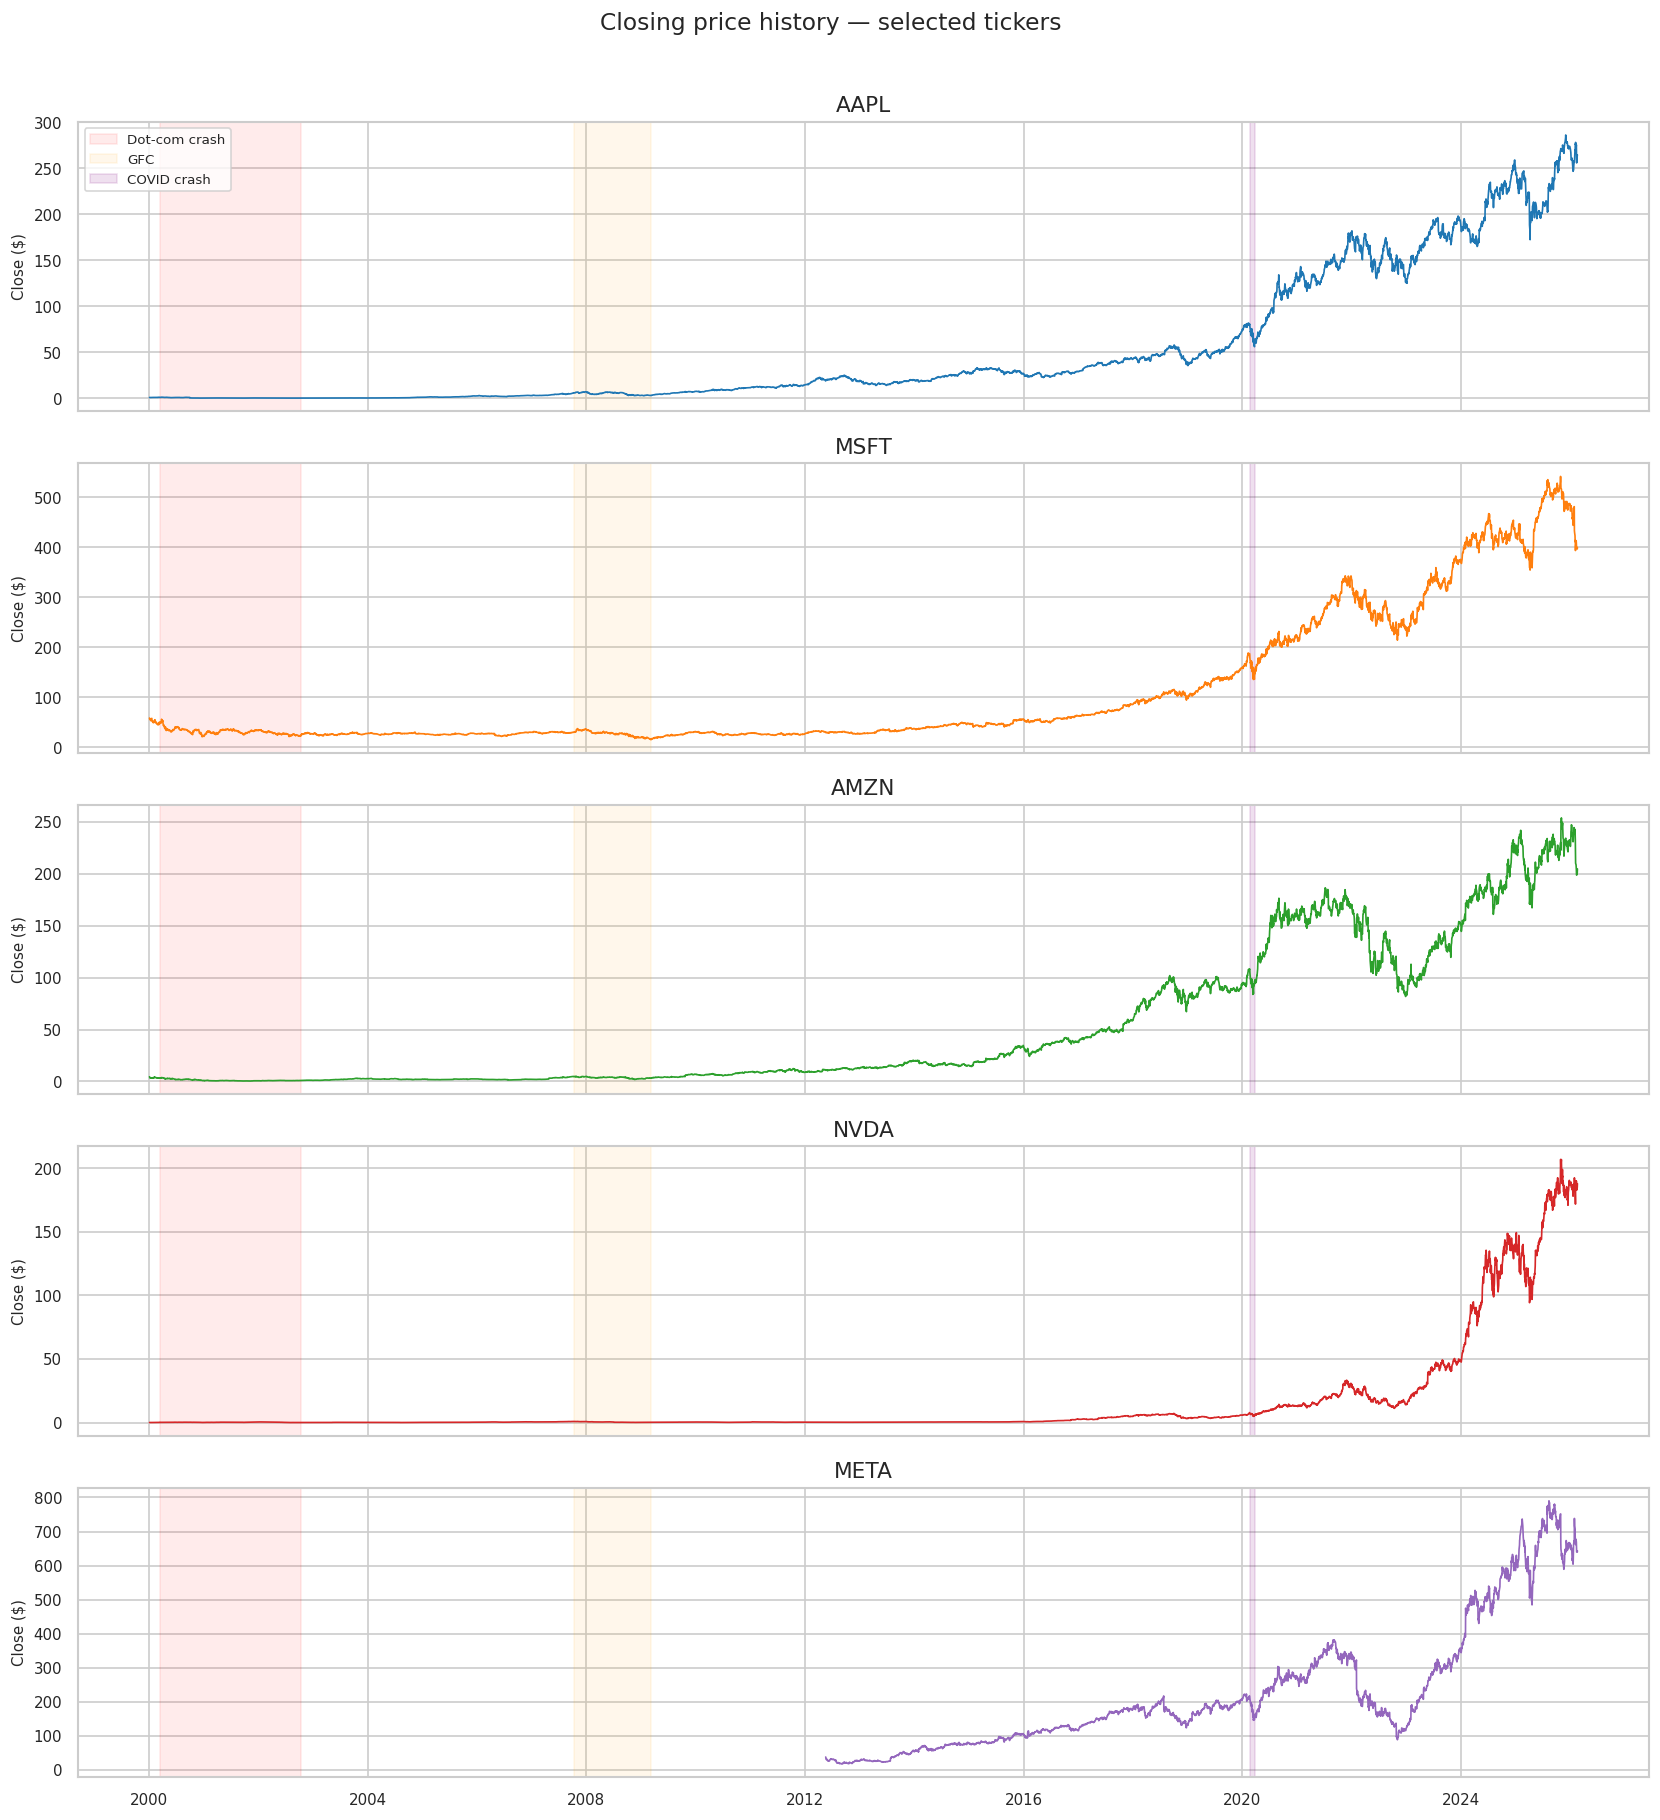

In [ ]:
fig, axes = plt.subplots(len(SAMPLE_TICKERS), 1,
                         figsize=(14, 3 * len(SAMPLE_TICKERS)),
                         sharex=True)

if len(SAMPLE_TICKERS) == 1:
    axes = [axes]

palette = sns.color_palette('tab10', len(SAMPLE_TICKERS))

for ax, ticker, color in zip(axes, SAMPLE_TICKERS, palette):
    sub = df[df['Ticker'] == ticker]
    ax.plot(sub['Date'], sub['Close'], lw=1, color=color)
    ax.set_ylabel('Close ($)', fontsize=9)
    ax.set_title(ticker)
    # Shade major bear markets
    ax.axvspan(pd.Timestamp('2000-03-10'), pd.Timestamp('2002-10-09'),
               alpha=0.08, color='red', label='Dot-com crash')
    ax.axvspan(pd.Timestamp('2007-10-09'), pd.Timestamp('2009-03-09'),
               alpha=0.08, color='orange', label='GFC')
    ax.axvspan(pd.Timestamp('2020-02-19'), pd.Timestamp('2020-03-23'),
               alpha=0.12, color='purple', label='COVID crash')

axes[0].legend(loc='upper left', fontsize=8)
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
fig.suptitle('Closing price history — selected tickers', y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

## Normalizovaná cena (základ = 100 pri prvom dni)


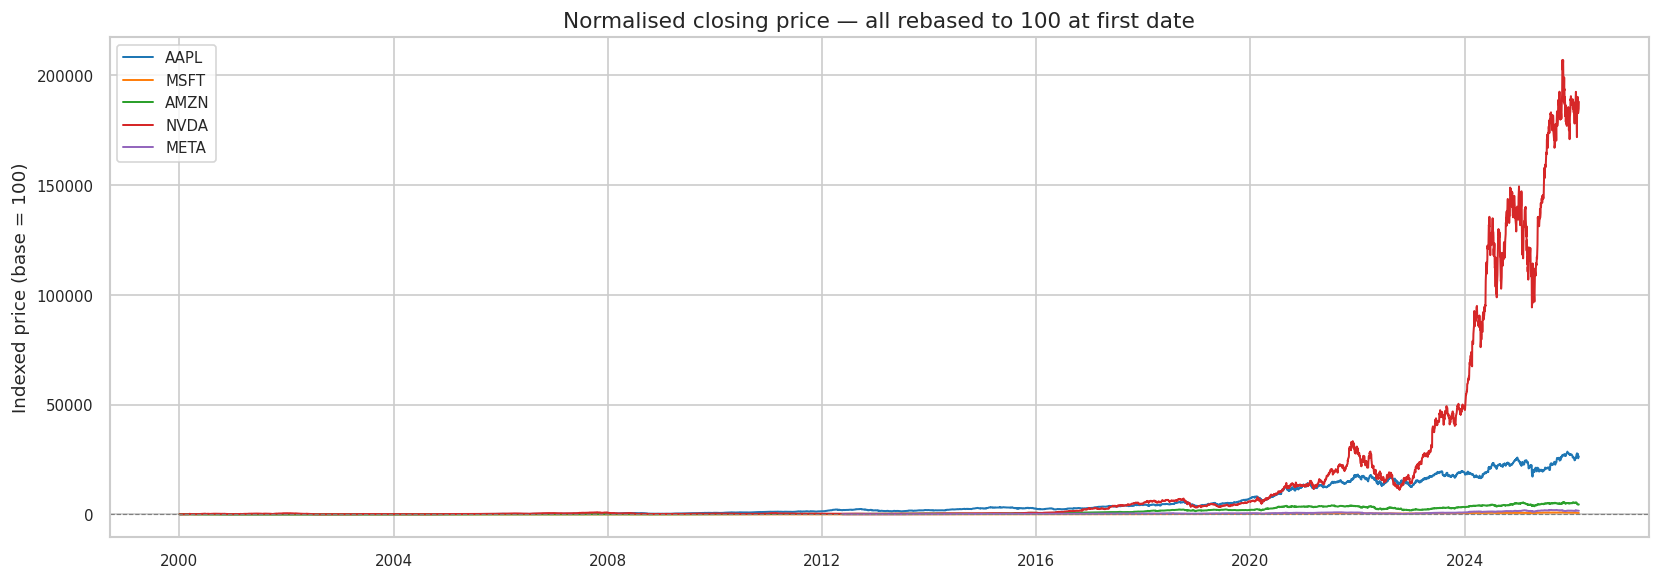


Notes:
  - Values above 100 mean the stock has grown since the start date.
  - Rebasing removes the distortion caused by different absolute price levels
    (e.g. comparing a $3 stock with a $3,000 stock on the same chart).
  - Steeper slopes = faster compounding growth.



In [ ]:
fig, ax = plt.subplots(figsize=(14, 5))
palette = sns.color_palette('tab10', len(SAMPLE_TICKERS))

for ticker, color in zip(SAMPLE_TICKERS, palette):
    sub = df[df['Ticker'] == ticker].set_index('Date')['Close']
    normalised = sub / sub.iloc[0] * 100
    ax.plot(normalised, lw=1.2, label=ticker, color=color)

ax.axhline(100, color='gray', lw=0.7, linestyle='--')
ax.set_ylabel('Indexed price (base = 100)')
ax.set_title('Normalised closing price — all rebased to 100 at first date')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.show()


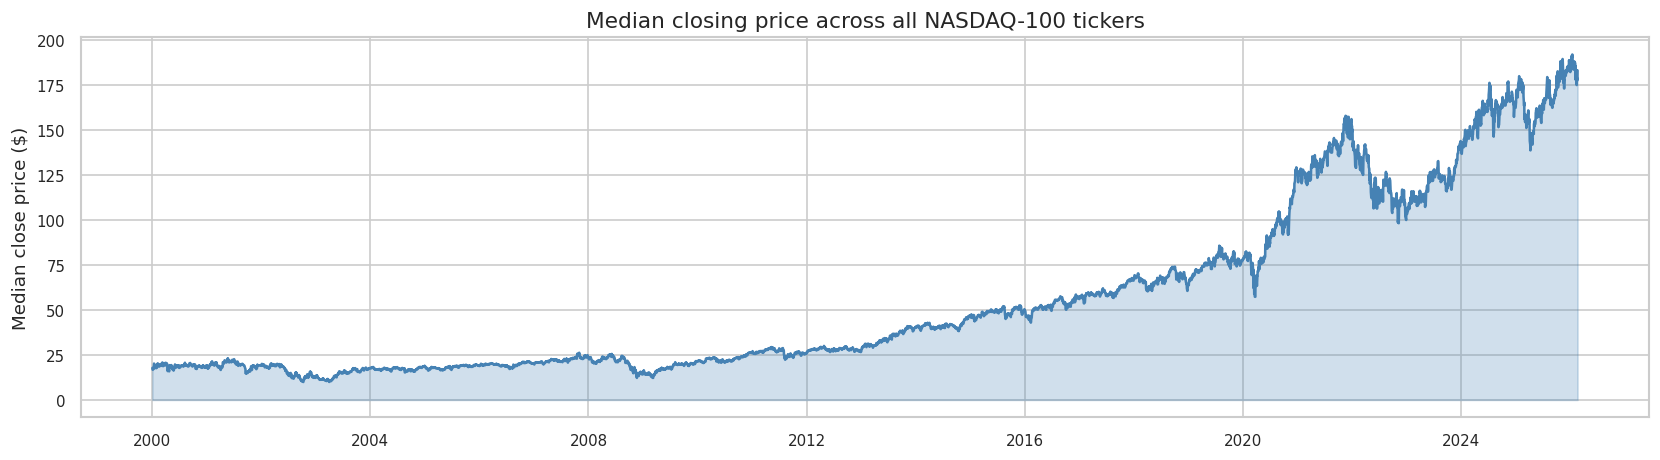


Notes:
  - Using the median (not mean) makes this resistant to extreme outliers
    like NVDA's recent >$500 price.
  - The shape mirrors the NASDAQ-100 index: the three major drawdowns
    (dot-com, GFC, COVID) are clearly visible as sharp drops.



In [ ]:
median_close = df.groupby('Date')['Close'].median()

fig, ax = plt.subplots(figsize=(14, 4))
ax.fill_between(median_close.index, median_close, alpha=0.25, color='steelblue')
ax.plot(median_close, lw=1.5, color='steelblue')
ax.set_ylabel('Median close price ($)')
ax.set_title('Median closing price across all NASDAQ-100 tickers')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.show()


## Distribúcie — histogramy a box ploty

Analyzovali sme distribúcie log returns, cien, objemu, denného rozsahu a rolling volatility.


In [ ]:

# Compute derived columns ---
df = df.sort_values(['Ticker', 'Date'])
df['Log_Return'] = df.groupby('Ticker')['Close'].transform(
    lambda x: np.log(x / x.shift(1))
)
df['Price_Range'] = df['High'] - df['Low']
df['Vol_30d'] = df.groupby('Ticker')['Log_Return'].transform(
    lambda x: x.rolling(30).std() * np.sqrt(252)  # annualised
)
df.head(40)

,Ticker,Date,Open,High,Low,Close,Adj Close,Volume,Log_Return,Price_Range,Vol_30d
0,AAPL,2000-01-03,0.94,1.00,0.91,1.00,0.84,535796800,NaN,0.09,NaN
1,AAPL,2000-01-04,0.97,0.99,0.90,0.92,0.77,512377600,-0.083382,0.09,NaN
2,AAPL,2000-01-05,0.93,0.99,0.92,0.93,0.78,778321600,0.010811,0.07,NaN
3,AAPL,2000-01-06,0.95,0.96,0.85,0.85,0.71,767972800,-0.089948,0.11,NaN
4,AAPL,2000-01-07,0.86,0.90,0.85,0.89,0.75,460734400,0.045985,0.05,NaN
5,AAPL,2000-01-10,0.91,0.91,0.85,0.87,0.73,505064000,-0.022728,0.06,NaN
6,AAPL,2000-01-11,0.86,0.89,0.81,0.83,0.69,441548800,-0.047068,0.08,NaN
7,AAPL,2000-01-12,0.85,0.85,0.77,0.78,0.65,976068800,-0.062132,0.08,NaN
8,AAPL,2000-01-13,0.84,0.88,0.83,0.86,0.72,1032684800,0.097638,0.05,NaN
9,AAPL,2000-01-14,0.89,0.91,0.89,0.90,0.75,390376000,0.045462,0.02,NaN


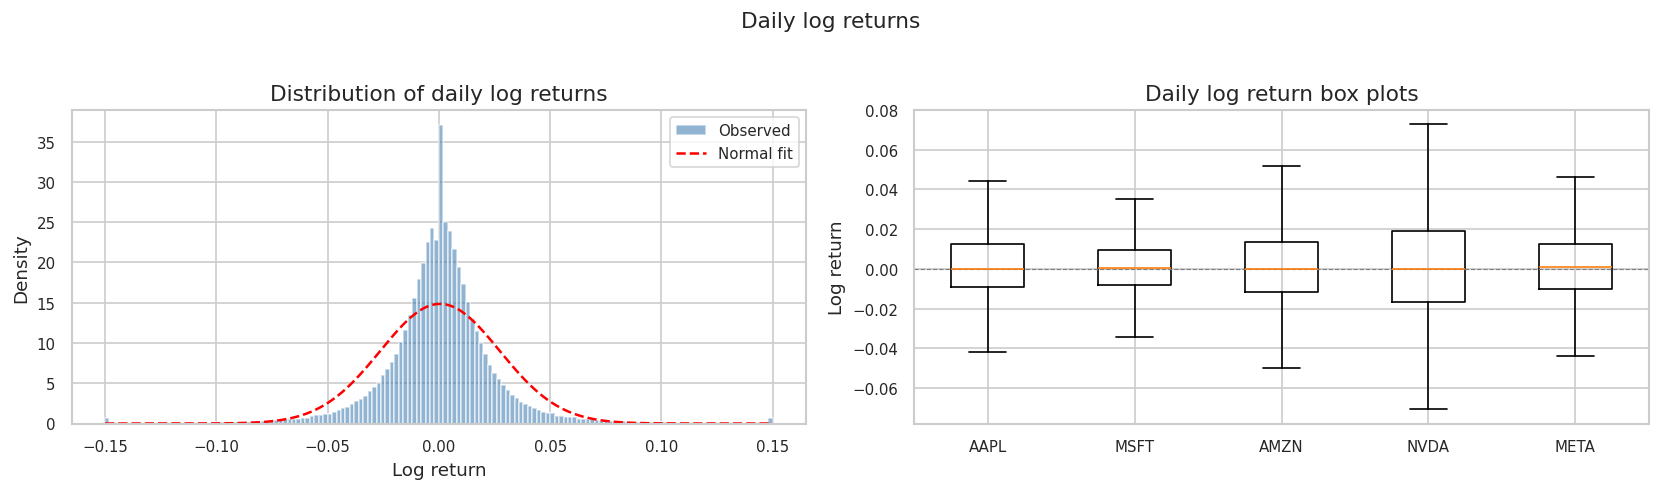

Skewness: -0.845  |  Excess kurtosis: 54.816

Notes:
  - The histogram is narrower and taller than the normal curve.
  Heavy tails — extreme returns happen far
    more often than a normal distribution would predict.
  - Slight negative skew: large down-days are more extreme than large up-days.
  - Box plots: the median return is close to zero for all tickers; differences
    in box width reflect each stock's typical daily volatility.
  - Use log returns (not raw price changes) to
    stabilise variance



In [ ]:
returns = df['Log_Return'].dropna()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.hist(returns.clip(-0.15, 0.15), bins=150, density=True,
         color='steelblue', alpha=0.6, label='Observed')
x = np.linspace(-0.15, 0.15, 300)
ax1.plot(x, stats.norm.pdf(x, returns.mean(), returns.std()),
         'r--', lw=1.5, label='Normal fit')
ax1.set_xlabel('Log return')
ax1.set_ylabel('Density')
ax1.set_title('Distribution of daily log returns')
ax1.legend()

# Box plot per sample ticker
sample_returns = [
    df[df['Ticker'] == t]['Log_Return'].dropna().values
    for t in SAMPLE_TICKERS
]
ax2.boxplot(sample_returns, labels=SAMPLE_TICKERS, showfliers=False)
ax2.axhline(0, color='gray', lw=0.7, linestyle='--')
ax2.set_ylabel('Log return')
ax2.set_title('Daily log return box plots')

plt.suptitle('Daily log returns', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

kurt = returns.kurtosis()
skew = returns.skew()
print(f'Skewness: {skew:.3f}  |  Excess kurtosis: {kurt:.3f}')

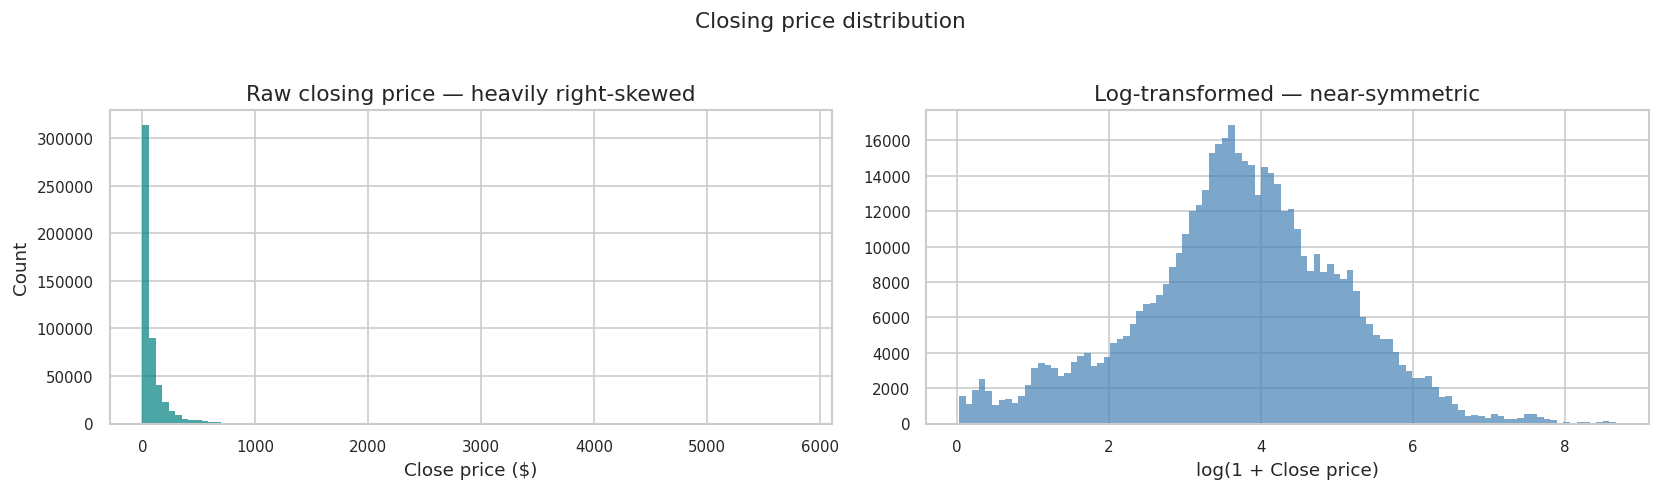

Mean close: $100.19  |  Median close: $40.80
Max close:  $5815.92  (BKNG)


In [ ]:
closes = df['Close'].dropna()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

# Raw histogram
ax1.hist(closes, bins=100, color='teal', alpha=0.7, edgecolor='none')
ax1.set_xlabel('Close price ($)')
ax1.set_ylabel('Count')
ax1.set_title('Raw closing price — heavily right-skewed')

# Log-scale histogram
ax2.hist(np.log1p(closes), bins=100, color='steelblue', alpha=0.7, edgecolor='none')
ax2.set_xlabel('log(1 + Close price)')
ax2.set_title('Log-transformed — near-symmetric')

plt.suptitle('Closing price distribution', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f'Mean close: ${closes.mean():.2f}  |  Median close: ${closes.median():.2f}')
print(f'Max close:  ${closes.max():.2f}  (BKNG)')

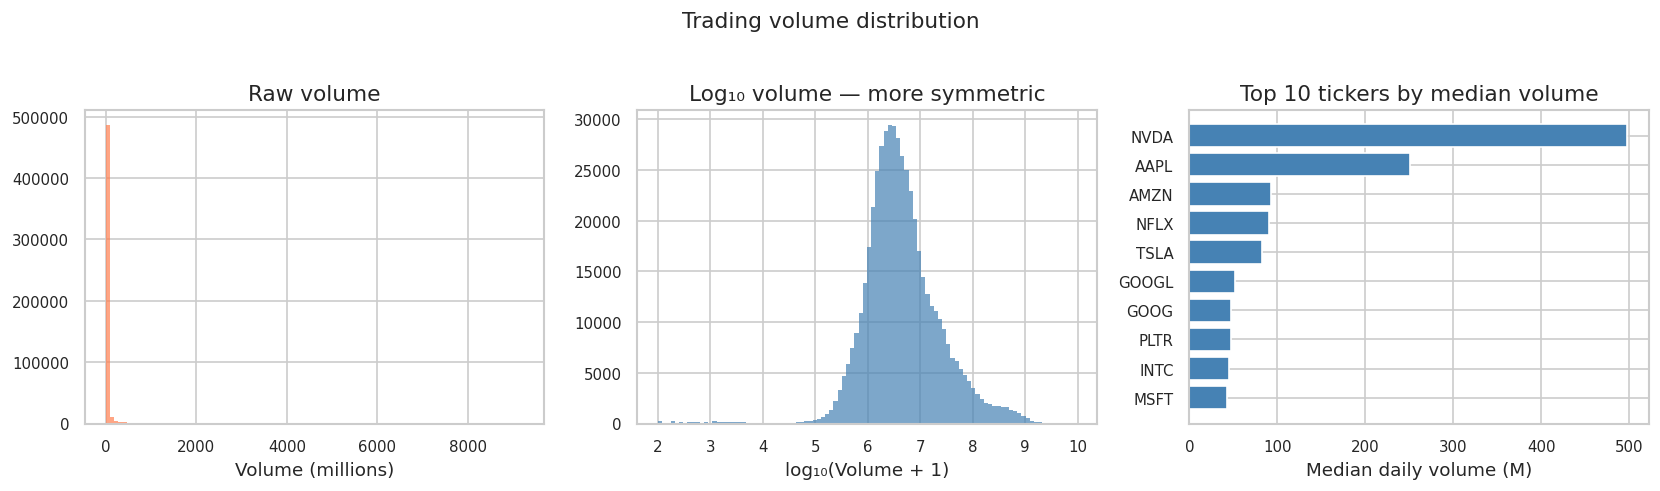


Notes:
  - High-volume tickers (AAPL, NVDA, MSFT) are the most liquid and have the
    cleanest price discovery — generally better for forecasting.



In [ ]:
volume = df['Volume'].replace(0, np.nan).dropna()

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].hist(volume / 1e6, bins=100, color='coral', alpha=0.7, edgecolor='none')
axes[0].set_xlabel('Volume (millions)')
axes[0].set_title('Raw volume')

axes[1].hist(np.log10(volume + 1), bins=100, color='steelblue', alpha=0.7, edgecolor='none')
axes[1].set_xlabel('log₁₀(Volume + 1)')
axes[1].set_title('Log₁₀ volume — more symmetric')

# Volume by ticker (top 10 by median volume)
top_vol = (df.groupby('Ticker')['Volume']
             .median()
             .sort_values(ascending=False)
             .head(10))
axes[2].barh(top_vol.index[::-1], top_vol.values[::-1] / 1e6, color='steelblue')
axes[2].set_xlabel('Median daily volume (M)')
axes[2].set_title('Top 10 tickers by median volume')

plt.suptitle('Trading volume distribution', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


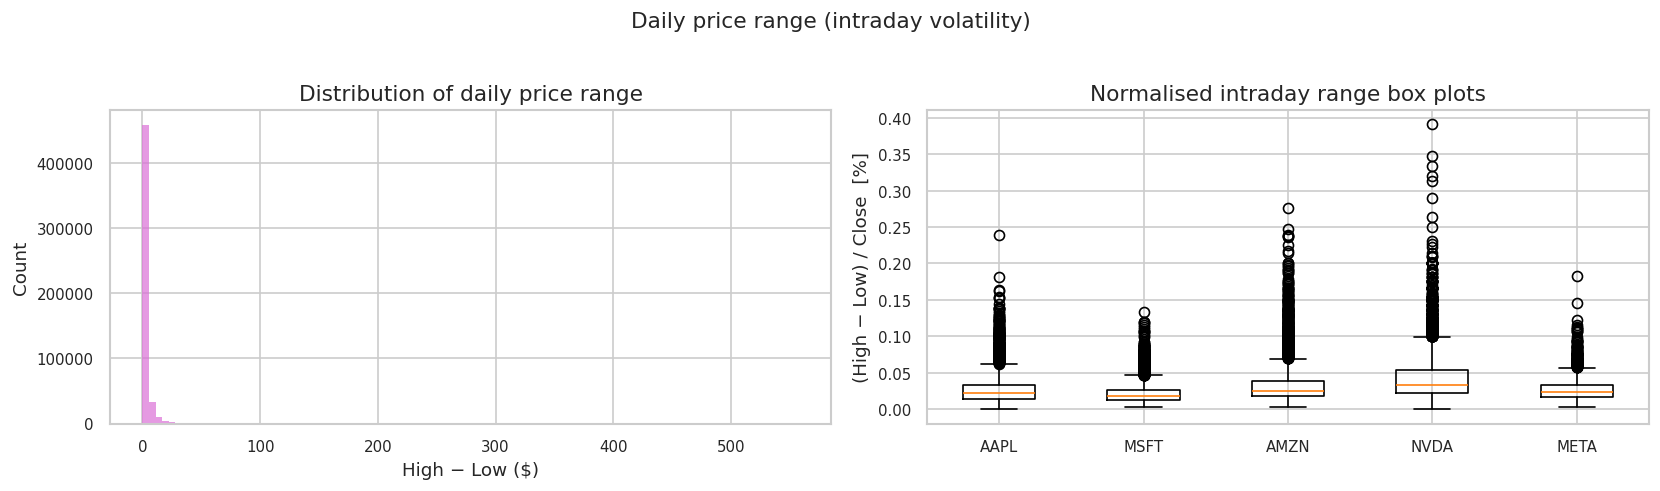


Note:
  - Outliers in the box plot correspond to extreme news events (earnings
    surprises, macro shocks) and are real signals, not data errors.



In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

price_range = df['Price_Range'].dropna()

ax1.hist(price_range, bins=100, color='orchid', alpha=0.7, edgecolor='none')
ax1.set_xlabel('High − Low ($)')
ax1.set_ylabel('Count')
ax1.set_title('Distribution of daily price range')

# Box plot per sample ticker (normalised by close to make comparable)
norm_ranges = [
    (df[df['Ticker'] == t]['Price_Range'] / df[df['Ticker'] == t]['Close']).dropna().values
    for t in SAMPLE_TICKERS
]
ax2.boxplot(norm_ranges, labels=SAMPLE_TICKERS)
ax2.set_ylabel('(High − Low) / Close  [%]')
ax2.set_title('Normalised intraday range box plots')

plt.suptitle('Daily price range (intraday volatility)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


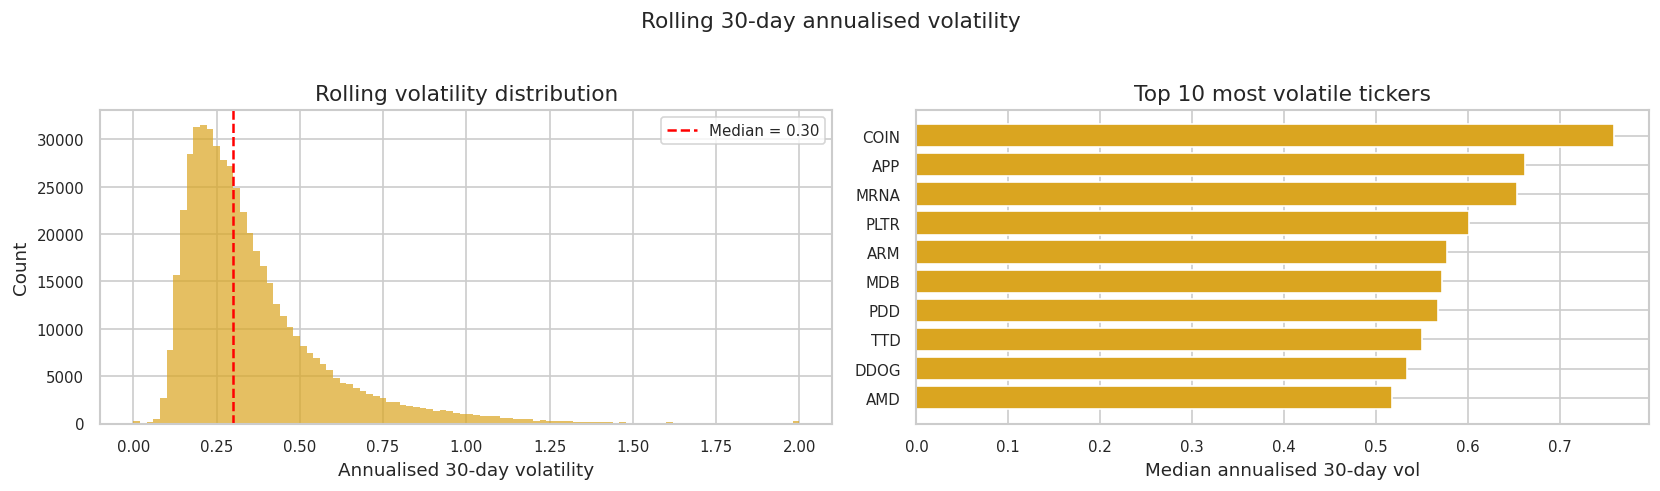


Notes:
  - Most tickers have annualised volatility between 0.2 (20%) and 0.6 (60%).
    Values above 1.0 (100%) reflect periods of extreme stress or thinly-traded
    smaller-cap names in the index.
  - The right tail (high vol) corresponds to crisis periods and high-beta
    growth stocks (NVDA, TSLA-class names).
  - Volatility is itself a useful feature: models that take vol as input can
    adaptively widen their prediction intervals during stressed periods.
  - Bimodal shape (two humps) is common: one mode for 'calm' regimes
    and one for 'stressed' regimes — a volatility-regime feature may help.



In [ ]:
vol_data = df['Vol_30d'].dropna()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.hist(vol_data.clip(0, 2), bins=100, color='goldenrod', alpha=0.7, edgecolor='none')
ax1.axvline(vol_data.median(), color='red', lw=1.5, linestyle='--', label=f'Median = {vol_data.median():.2f}')
ax1.set_xlabel('Annualised 30-day volatility')
ax1.set_ylabel('Count')
ax1.set_title('Rolling volatility distribution')
ax1.legend()

# Per-ticker median vol (top 10 most volatile)
tick_vol = df.groupby('Ticker')['Vol_30d'].median().sort_values(ascending=False).head(10)
ax2.barh(tick_vol.index[::-1], tick_vol.values[::-1], color='goldenrod')
ax2.set_xlabel('Median annualised 30-day vol')
ax2.set_title('Top 10 most volatile tickers')

plt.suptitle('Rolling 30-day annualised volatility', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


## Korelačná matica

Korelácia medzi OHLC hodnotami v rámci tickera a korelácie log returns medzi tickermi.


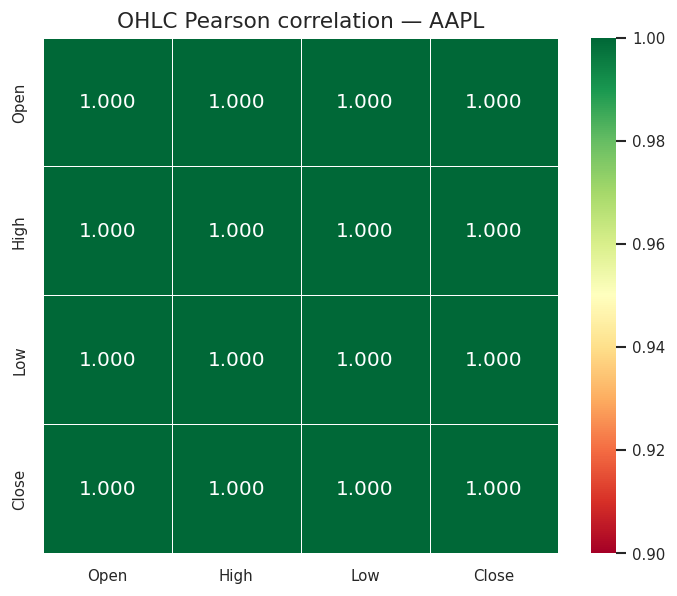


Interpretation:
  By the definiton it should be highly correlated



In [ ]:
# 5.1  Within-ticker OHLC Pearson correlation ---
# Use a single, well-covered ticker as the representative example
ref_ticker = SAMPLE_TICKERS[0] if SAMPLE_TICKERS else TICKERS[0]
ohlc = df[df['Ticker'] == ref_ticker][['Open', 'High', 'Low', 'Close']].dropna()
corr_ohlc = ohlc.corr()

fig, ax = plt.subplots(figsize=(6, 5))
mask = np.triu(np.ones_like(corr_ohlc, dtype=bool), k=1)  # show lower triangle only
sns.heatmap(corr_ohlc, annot=True, fmt='.3f', cmap='RdYlGn',
            vmin=0.9, vmax=1.0, ax=ax,
            linewidths=0.5, square=True)
ax.set_title(f'OHLC Pearson correlation — {ref_ticker}')
plt.tight_layout()
plt.show()


In [ ]:
# Flatten upper triangle
pivot = (df.pivot_table(index='Date', columns='Ticker', values='Log_Return')
           .dropna(axis=1, thresh=int(0.7 * df['Date'].nunique()))  # drop sparse tickers
           .fillna(0))

cross_corr = pivot.corr()

corr_pairs = (
    cross_corr.rename_axis(index='Ticker_A', columns='Ticker_B')
    .where(np.triu(np.ones(cross_corr.shape), k=1).astype(bool))
    .stack()
    .reset_index(name='Correlation')
)

print('Top 10 most correlated pairs:')
print(corr_pairs.sort_values('Correlation', ascending=False).head(10).to_string(index=False))
print()
print('Top 10 least correlated pairs:')
print(corr_pairs.sort_values('Correlation').head(10).to_string(index=False))

Top 10 most correlated pairs:
Ticker_A Ticker_B  Correlation
    GOOG    GOOGL     0.997072
    AMAT     KLAC     0.825434
    AMAT     LRCX     0.822702
    KLAC     LRCX     0.818207
     ADI      TXN     0.762574
    ASML     LRCX     0.720795
     ADI     MCHP     0.719213
    AMAT     ASML     0.712948
    MCHP      TXN     0.711373
    ASML     KLAC     0.701785

Top 10 least correlated pairs:
Ticker_A Ticker_B  Correlation
    MNST     REGN     0.058274
    MNST     VRTX     0.064804
    AMGN     MNST     0.070460
    MNST     NFLX     0.072057
    BIIB     MNST     0.073306
    SMCI      XEL     0.080138
    MNST      XEL     0.082190
     AEP     SMCI     0.084854
    DLTR     MNST     0.085848
    GILD     MNST     0.087952


## Chýbajúce hodnoty a outliers

Finančné dáta majú špecifické problémy — sviatky, nulové objemy, extrémne výkyvy. Odlíšili sme legitímne extrémne hodnoty (crash days) od dátových chýb.


In [ ]:
missing = df.isnull().sum()
missing_pct = (df.isnull().mean() * 100).round(2)

print('=== Missing value summary ===')
print(pd.concat([missing.rename('Count'), missing_pct.rename('Pct %')], axis=1))


=== Missing value summary ===
             Count  Pct %
Ticker           0   0.00
Date             0   0.00
Open             0   0.00
High             0   0.00
Low              0   0.00
Close            0   0.00
Adj Close        0   0.00
Volume           0   0.00
Log_Return     100   0.02
Price_Range      0   0.00
Vol_30d       3000   0.58


In [ ]:
zero_vol = df[df['Volume'] == 0]
print(f'Zero-volume rows: {len(zero_vol):,} ({len(zero_vol)/len(df)*100:.2f}%)')
print(zero_vol[['Date', 'Ticker', 'Open', 'High', 'Low', 'Close', 'Volume']].head(10))

Zero-volume rows: 1,594 (0.31%)
            Date Ticker   Open   High    Low  Close  Volume
51072 2015-01-02    AMD   2.67   2.67   2.67   2.67       0
79569 2009-02-17    AZN  37.10  37.10  37.10  37.10       0
79570 2009-02-18    AZN  37.10  37.10  37.10  37.10       0
79571 2009-02-19    AZN  37.10  37.10  37.10  37.10       0
79573 2009-02-23    AZN  35.25  35.25  35.25  35.25       0
79575 2009-02-25    AZN  35.25  35.25  35.25  35.25       0
79576 2009-02-26    AZN  35.25  35.25  35.25  35.25       0
79577 2009-02-27    AZN  35.25  35.25  35.25  35.25       0
79578 2009-03-02    AZN  35.25  35.25  35.25  35.25       0
79580 2009-03-04    AZN  32.05  32.05  32.05  32.05       0


In [ ]:
# Flag rows where the log return is more than 4 standard deviations from the
# ticker's own mean (per-ticker z-score avoids penalising volatile stocks).

df['Return_Zscore'] = df.groupby('Ticker')['Log_Return'].transform(
    lambda x: (x - x.mean()) / x.std()
)
Z_THRESH = 4
outliers = df[df['Return_Zscore'].abs() > Z_THRESH].copy()

print(f'Outlier rows (|z| > {Z_THRESH}): {len(outliers):,} ({len(outliers)/len(df)*100:.3f}%)')
print()
print('Largest positive outliers (biggest single-day surges):')
print(outliers.nlargest(10, 'Log_Return')[['Date', 'Ticker', 'Close', 'Log_Return', 'Return_Zscore']]
      .to_string(index=False))
print()
print('Largest negative outliers (biggest single-day crashes):')
print(outliers.nsmallest(10, 'Log_Return')[['Date', 'Ticker', 'Close', 'Log_Return', 'Return_Zscore']]
      .to_string(index=False))

Outlier rows (|z| > 4): 3,517 (0.684%)

Largest positive outliers (biggest single-day surges):
      Date Ticker  Close  Log_Return  Return_Zscore
2000-02-23   REGN  36.62    0.561803      15.712128
2013-04-19   VRTX  85.60    0.481849      14.670460
2022-03-16    PDD  42.62    0.445071      10.172900
2002-01-03     ON   3.50    0.441833      11.644295
2012-05-07   VRTX  58.12    0.440572      13.412441
2008-02-25   TTWO  26.89    0.437586      14.350989
2016-04-22    AMD   3.99    0.420617      10.851338
2008-12-04   DXCM   0.75    0.405465      11.715203
2024-02-08    ARM 113.89    0.391298       8.842261
2024-11-07    APP 246.53    0.380251       7.885413

Largest negative outliers (biggest single-day crashes):
      Date Ticker  Close  Log_Return  Return_Zscore
2018-07-10    KDP  22.19   -1.717894     -57.184747
2003-03-31   REGN   7.52   -0.833718     -23.360963
2000-09-29   AAPL   0.46   -0.735707     -28.938022
2020-03-09   FANG  26.88   -0.591418     -19.431033
2000-12-19   DLT

In [ ]:
# Useful to catch suspiciously high or low prices (possible data entry errors).

def iqr_bounds(series, factor=3.0):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    return q1 - factor * iqr, q3 + factor * iqr

lo, hi = iqr_bounds(df['Close'])
price_outliers = df[(df['Close'] < lo) | (df['Close'] > hi)]
print(f'Price outliers (IQR ×3): {len(price_outliers):,} rows')
print(price_outliers[['Date', 'Ticker', 'Close']].head(10))


Price outliers (IQR ×3): 27,328 rows
            Date Ticker   Close
12904 2020-01-02   ADBE  334.43
12906 2020-01-06   ADBE  333.71
12908 2020-01-08   ADBE  337.87
12909 2020-01-09   ADBE  340.45
12910 2020-01-10   ADBE  339.81
12911 2020-01-13   ADBE  345.63
12912 2020-01-14   ADBE  344.63
12913 2020-01-15   ADBE  342.94
12914 2020-01-16   ADBE  345.38
12915 2020-01-17   ADBE  349.74

Notes:
  - IQR outliers for closing price are mostly high-priced tickers
    (e.g. AMZN before its 20:1 split). These are NOT errors — they reflect
    genuine share prices and should NOT be removed or capped.
  - Z-score outliers in returns (|z| > 4) include both real market events
    (COVID crash, earnings surprises) and potential data errors.
  - Decision rule:
      * |return| < 50% in one day → plausible market event → keep.
      * |return| > 50% or price drops to near zero → investigate → flag or remove.
  - For modelling: winsorising returns at the 1st/99th percentile is a common
    robust pre

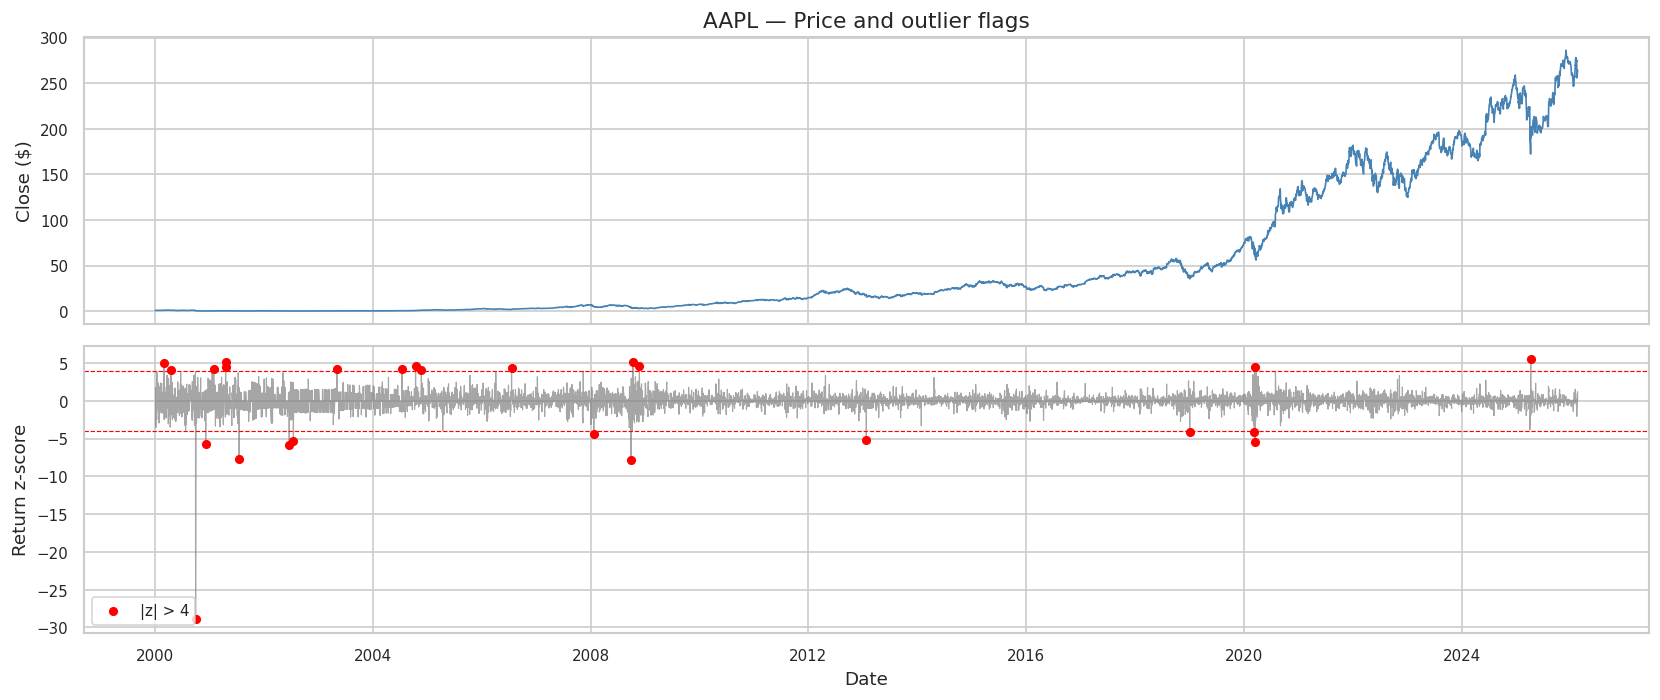


Interpretation:
  - Red dots on the z-score chart mark days where the return was statistically
    extreme for that specific ticker.
  - Cross-referencing with the price chart: if a dot-com era spike aligns with
    a known earnings event, it is legitimate signal.
  - If a spike has no corresponding price-level move visible on the top chart
    (implying a one-day error then reversion), that is a data quality problem.



In [ ]:
ref = SAMPLE_TICKERS[0]
sub = df[df['Ticker'] == ref].set_index('Date')

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

ax1.plot(sub.index, sub['Close'], lw=1, color='steelblue')
ax1.set_ylabel('Close ($)')
ax1.set_title(f'{ref} — Price and outlier flags')

outlier_days = sub[sub['Return_Zscore'].abs() > Z_THRESH]
ax2.plot(sub.index, sub['Return_Zscore'], lw=0.7, color='gray', alpha=0.7)
ax2.scatter(outlier_days.index, outlier_days['Return_Zscore'],
            color='red', s=20, zorder=5, label=f'|z| > {Z_THRESH}')
ax2.axhline(Z_THRESH, color='red', lw=0.7, linestyle='--')
ax2.axhline(-Z_THRESH, color='red', lw=0.7, linestyle='--')
ax2.set_ylabel('Return z-score')
ax2.set_xlabel('Date')
ax2.legend()
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.show()


In [ ]:
summary = {
    'Metric': [
        'Total rows', 'Unique tickers', 'Date range', 'Missing values',
        'Zero-volume rows', 'Return outliers (|z|>4)', 'Return skewness',
        'Return excess kurtosis', 'Median annualised vol'
    ],
    'Value': [
        f'{len(df):,}',
        str(df["Ticker"].nunique()),
        f'{df["Date"].min().date()} → {df["Date"].max().date()}',
        str(df.isnull().sum().sum()),
        str(len(df[df['Volume'] == 0])),
        str(len(outliers)),
        f'{returns.skew():.3f}',
        f'{returns.kurtosis():.3f}',
        f'{vol_data.median():.3f}'
    ]
}
pd.DataFrame(summary)

,Metric,Value
0,Total rows,"514,075"
1,Unique tickers,100
2,Date range,2000-01-03 → 2026-02-18
3,Missing values,3200
4,Zero-volume rows,1594
5,Return outliers (|z|>4),3517
6,Return skewness,-0.845
7,Return excess kurtosis,54.816
8,Median annualised vol,0.299


## Závery z EDA

- Log returns majú fat tails — nie sú normálne rozdelené
- OHLC hodnoty sú vysoko korelované (R > 0.99)
- Tickery tvoria korelačné zhluky podľa sektora
- Volume a volatilita majú vzory použiteľné ako features


# Príprava dát


## Setup


In [ ]:
import os, glob, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 12, 'axes.labelsize': 10})

In [ ]:
ARTEFACT_PATH = './artefacts'
os.makedirs(ARTEFACT_PATH, exist_ok=True)

df = pd.read_csv("/content/NASDAQ100_Historical_Data.csv", parse_dates=['Date'])
df.head(3)

,Ticker,Date,Open,High,Low,Close,Adj Close,Volume
0,AAPL,2000-01-03,0.94,1.00,0.91,1.00,0.84,535796800
1,AAPL,2000-01-04,0.97,0.99,0.90,0.92,0.77,512377600
2,AAPL,2000-01-05,0.93,0.99,0.92,0.93,0.78,778321600


## Čistenie dát

Odstránili sme tickery s nedostatočnou históriou, opravili nulové objemy a ošetrili extrémne výkyvy (winsorácia log returns na 1%/99%).


In [ ]:
MIN_DAYS = 1000   # ~4 trading years
coverage = df.groupby('Ticker').size()
valid_tickers = coverage[coverage >= MIN_DAYS].index.tolist()
dropped = set(df['Ticker'].unique()) - set(valid_tickers)

df = df[df['Ticker'].isin(valid_tickers)].copy()
print(f'Tickers kept : {len(valid_tickers)}')
print(f'Tickers dropped (< {MIN_DAYS} days): {sorted(dropped)}')

Tickers kept : 98
Tickers dropped (< 1000 days): ['ARM', 'GEHC']


In [ ]:
df['Adj_Close'] = df['Adj Close']
adj_ratio       = df['Adj_Close'] / df['Close']

for col in ['Open', 'High', 'Low', 'Close']:
    df[col] = df[col] * adj_ratio

max_diff = (df['Close'] - df['Adj_Close']).abs().max()
assert max_diff < 1e-6, f"Adjustment failed — max diff = {max_diff}"

df = df.drop(columns=['Adj Close', 'Adj_Close'])

print('Split/dividend adjustment applied to OHLC columns.')
print(f'  Max |Close - Adj_Close| after adjustment: {max_diff:.2e}  (should be ~0)')
print(f'  Shape: {df.shape}')
print(f'  Columns: {df.columns.tolist()}')
print()

aapl_split = df[(df['Ticker'] == 'AAPL') &
                (df['Date'] >= '2020-08-28') &
                (df['Date'] <= '2020-09-02')]
if len(aapl_split) > 0:
    print('AAPL around 4:1 split (2020-08-31) — adjusted prices:')
    print(aapl_split[['Date', 'Open', 'High', 'Low', 'Close', 'Volume']].to_string(index=False))
    print('  (Prices should be smooth across the split date, no sudden 75% drop)')


Split/dividend adjustment applied to OHLC columns.
  Max |Close - Adj_Close| after adjustment: 5.68e-14  (should be ~0)
  Shape: (512671, 7)
  Columns: ['Ticker', 'Date', 'Open', 'High', 'Low', 'Close', 'Volume']

AAPL around 4:1 split (2020-08-31) — adjusted prices:
      Date       Open       High        Low  Close    Volume
2020-08-28 122.335003 122.752462 120.946708 121.17 187630000
2020-08-31 123.862542 127.182889 122.328580 125.28 225702700
2020-09-01 128.891379 130.871933 126.726361 130.27 151948100
2020-09-02 133.579576 133.958209 123.298250 127.57 200119000
  (Prices should be smooth across the split date, no sudden 75% drop)


In [ ]:
df = df.sort_values(['Ticker', 'Date'])
df['Log_Return'] = df.groupby('Ticker')['Close'].transform(
    lambda x: np.log(x / x.shift(1))
)

# Winsorise per ticker at 1st / 99th percentile
def winsorise(series, lo=0.01, hi=0.99):
    q_lo, q_hi = series.quantile(lo), series.quantile(hi)
    return series.clip(q_lo, q_hi)

df['Log_Return'] = df.groupby('Ticker')['Log_Return'].transform(winsorise)

print('Log return summary after winsorisation:')
print(df['Log_Return'].describe().round(5))

Log return summary after winsorisation:
count    512573.00000
mean          0.00056
std           0.02360
min          -0.12920
25%          -0.01021
50%           0.00025
75%           0.01152
max           0.14820
Name: Log_Return, dtype: float64


In [ ]:
print(f'Clean dataframe shape : {df.shape}')
print(f'Remaining NaN count   : {df.isnull().sum().sum()}')
print(f'Date range            : {df["Date"].min().date()} → {df["Date"].max().date()}')
print(f'Tickers               : {df["Ticker"].nunique()}')

Clean dataframe shape : (512671, 8)
Remaining NaN count   : 98
Date range            : 2000-01-03 → 2026-02-18
Tickers               : 98


# Configured baseline regresia z mini-projektu 1

V tejto sekcii trénujeme klasické regresné modely (Linear Regression, Ridge, Random Forest)
ako baseline pre porovnanie s deep learning prístupom (LSTM).

- **Tréning:** 2016–2018 (3 roky, stabilné obdobie)
- **Test:** jan–jun 2019
- **Horizont:** 1 deň dopredu (next-day close)
- **Features:** 12 jednoduchých features z datasetu


### Feature engineering

Použili sme 12 features: Open, High, Low, Close, Volume + lagy Close (1–3 dni) + Volume_Lag1 + SMA_5, SMA_20 + Daily_Range.


In [ ]:
# Výber tickerov na analýzu
TICKERS_TO_PREDICT = ['AAPL', 'MSFT', 'AMZN', 'NVDA', 'GOOG']
TICKERS_TO_PREDICT = [t for t in TICKERS_TO_PREDICT if t in df['Ticker'].unique()]

# Tréningové a testovacie obdobie (na základe spätnej väzby)
TRAIN_START = '2016-01-01'
TRAIN_END   = '2018-12-31'
TEST_START  = '2019-01-01'
TEST_END    = '2019-06-30'   # predikcia na pár mesiacov

print(f'Tréning: {TRAIN_START} → {TRAIN_END}')
print(f'Test:    {TEST_START} → {TEST_END}')
print(f'Tickery: {TICKERS_TO_PREDICT}')


Tréning: 2016-01-01 → 2018-12-31
Test:    2019-01-01 → 2019-06-30
Tickery: ['AAPL', 'MSFT', 'AMZN', 'NVDA', 'GOOG']


In [ ]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

def prepare_features(ticker_df):
    """
    Pripravi features pre jeden ticker.
    Pouziva existujuce features + jednoduche lagy a kĺzavé priemery.
    """
    d = ticker_df.copy()
    d = d.sort_values('Date')

    # Lagy close ceny (1, 2, 3 dni dozadu)
    d['Close_Lag1'] = d['Close'].shift(1)
    d['Close_Lag2'] = d['Close'].shift(2)
    d['Close_Lag3'] = d['Close'].shift(3)

    # Lag volume
    d['Volume_Lag1'] = d['Volume'].shift(1)

    # Jednoduche kĺzave priemery
    d['SMA_5']  = d['Close'].rolling(5).mean()
    d['SMA_20'] = d['Close'].rolling(20).mean()

    # Denny rozptyl
    d['Daily_Range'] = d['High'] - d['Low']

    # Target: zajtrajsia close cena
    d['Target'] = d['Close'].shift(-1)

    # Odstranit riadky s NaN (kvoli lagom a rolling)
    d = d.dropna()

    return d

FEATURE_COLS = ['Open', 'High', 'Low', 'Close', 'Volume',
                'Close_Lag1', 'Close_Lag2', 'Close_Lag3',
                'Volume_Lag1', 'SMA_5', 'SMA_20', 'Daily_Range']

print(f'Pocet features: {len(FEATURE_COLS)}')
print(f'Features: {FEATURE_COLS}')


Pocet features: 12
Features: ['Open', 'High', 'Low', 'Close', 'Volume', 'Close_Lag1', 'Close_Lag2', 'Close_Lag3', 'Volume_Lag1', 'SMA_5', 'SMA_20', 'Daily_Range']


In [ ]:
# Trenovanie a evaluacia pre kazdy ticker

results = []

for ticker in TICKERS_TO_PREDICT:
    print(f'\n{"="*60}')
    print(f'  {ticker}')
    print(f'{"="*60}')

    # Priprava dat pre tento ticker
    ticker_df = df[df['Ticker'] == ticker].copy()
    ticker_df = prepare_features(ticker_df)

    # Split na train a test podla datumu
    train = ticker_df[(ticker_df['Date'] >= TRAIN_START) & (ticker_df['Date'] <= TRAIN_END)]
    test  = ticker_df[(ticker_df['Date'] >= TEST_START) & (ticker_df['Date'] <= TEST_END)]

    if len(train) < 50 or len(test) < 10:
        print(f'  Nedostatok dat! Train={len(train)}, Test={len(test)}')
        continue

    X_train = train[FEATURE_COLS].values
    y_train = train['Target'].values
    X_test  = test[FEATURE_COLS].values
    y_test  = test['Target'].values

    print(f'  Train: {len(train)} dni ({train["Date"].min().date()} - {train["Date"].max().date()})')
    print(f'  Test:  {len(test)} dni ({test["Date"].min().date()} - {test["Date"].max().date()})')

    # --- Model 1: Linearna regresia (BASELINE) ---
    lr = LinearRegression()
    lr.fit(X_train, y_train)
    lr_pred = lr.predict(X_test)
    lr_r2 = r2_score(y_test, lr_pred)
    lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
    lr_mae = mean_absolute_error(y_test, lr_pred)

    # --- Model 2: Ridge regresia ---
    ridge = Ridge(alpha=1.0)
    ridge.fit(X_train, y_train)
    ridge_pred = ridge.predict(X_test)
    ridge_r2 = r2_score(y_test, ridge_pred)
    ridge_rmse = np.sqrt(mean_squared_error(y_test, ridge_pred))
    ridge_mae = mean_absolute_error(y_test, ridge_pred)

    # --- Model 3: Random Forest ---
    rf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
    rf.fit(X_train, y_train)
    rf_pred = rf.predict(X_test)
    rf_r2 = r2_score(y_test, rf_pred)
    rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
    rf_mae = mean_absolute_error(y_test, rf_pred)

    print(f'\n  Vysledky:')
    print(f'  {"Model":<25} {"R²":>8} {"RMSE":>10} {"MAE":>10}')
    print(f'  {"-"*55}')
    print(f'  {"Linear Regression":<25} {lr_r2:>8.4f} {lr_rmse:>10.4f} {lr_mae:>10.4f}')
    print(f'  {"Ridge (alpha=1.0)":<25} {ridge_r2:>8.4f} {ridge_rmse:>10.4f} {ridge_mae:>10.4f}')
    print(f'  {"Random Forest":<25} {rf_r2:>8.4f} {rf_rmse:>10.4f} {rf_mae:>10.4f}')

    results.append({
        'Ticker': ticker,
        'LR_R2': lr_r2, 'LR_RMSE': lr_rmse, 'LR_MAE': lr_mae,
        'Ridge_R2': ridge_r2, 'Ridge_RMSE': ridge_rmse, 'Ridge_MAE': ridge_mae,
        'RF_R2': rf_r2, 'RF_RMSE': rf_rmse, 'RF_MAE': rf_mae,
        'test_dates': test['Date'].values,
        'y_test': y_test,
        'lr_pred': lr_pred,
        'ridge_pred': ridge_pred,
        'rf_pred': rf_pred,
    })



  AAPL
  Train: 754 dni (2016-01-04 - 2018-12-31)
  Test:  124 dni (2019-01-02 - 2019-06-28)

  Vysledky:
  Model                           R²       RMSE        MAE
  -------------------------------------------------------
  Linear Regression           0.9633     0.7875     0.5465
  Ridge (alpha=1.0)           0.9633     0.7871     0.5464
  Random Forest               0.9563     0.8589     0.6408

  MSFT
  Train: 754 dni (2016-01-04 - 2018-12-31)
  Test:  124 dni (2019-01-02 - 2019-06-28)

  Vysledky:
  Model                           R²       RMSE        MAE
  -------------------------------------------------------
  Linear Regression           0.9780     1.4811     1.1338
  Ridge (alpha=1.0)           0.9780     1.4813     1.1338
  Random Forest              -0.1659    10.7932     8.0791

  AMZN
  Train: 754 dni (2016-01-04 - 2018-12-31)
  Test:  124 dni (2019-01-02 - 2019-06-28)

  Vysledky:
  Model                           R²       RMSE        MAE
  ------------------------------

### Actual vs Predicted


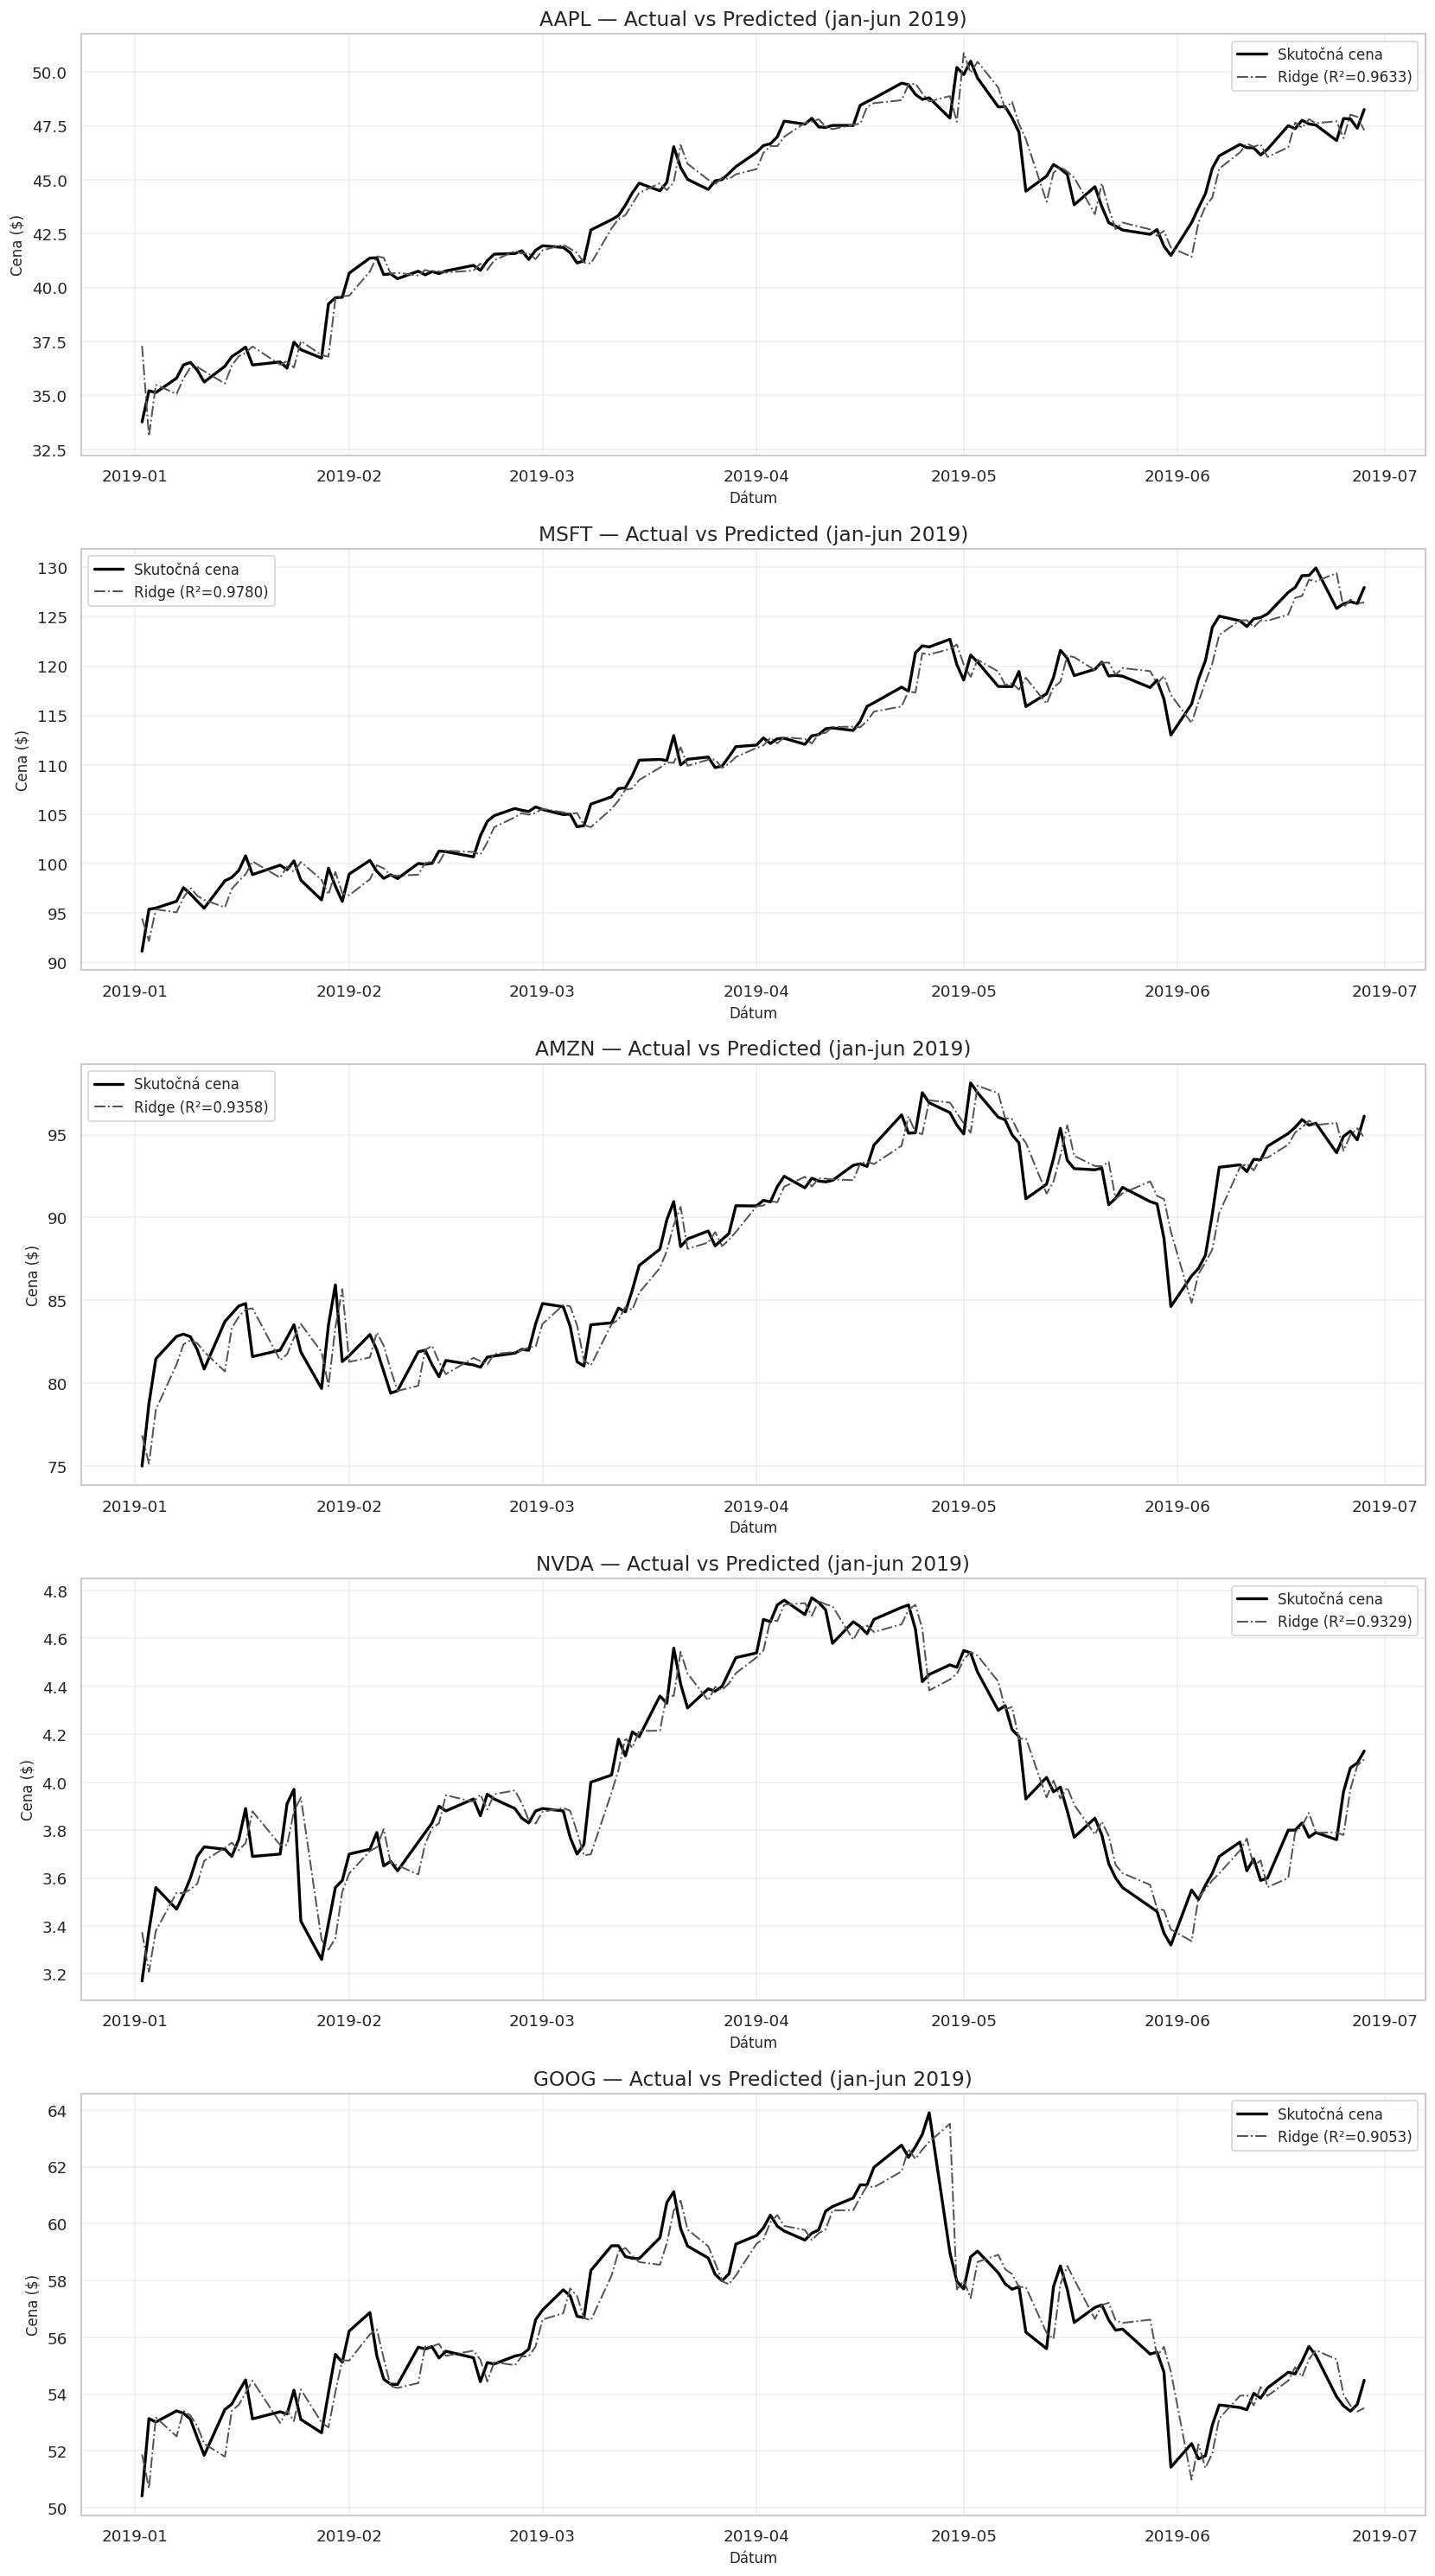

In [ ]:
# Hlavny vystup: dve krivky (actual vs predicted) pre kazdy ticker

fig, axes = plt.subplots(len(results), 1, figsize=(14, 5 * len(results)), squeeze=False)

for i, res in enumerate(results):
    ax = axes[i][0]
    dates = pd.to_datetime(res['test_dates'])

    # Actual price
    ax.plot(dates, res['y_test'], color='black', linewidth=2, label='Skutočná cena')

    # Predicted prices
    # ax.plot(dates, res['lr_pred'], color='#888888', linewidth=1.2, linestyle='--',
    #         label=f'Linear Regression (R²={res["LR_R2"]:.4f})')
    ax.plot(dates, res['ridge_pred'], color='#555555', linewidth=1.2, linestyle='-.',
            label=f'Ridge (R²={res["Ridge_R2"]:.4f})')
    # ax.plot(dates, res['rf_pred'], color='#333333', linewidth=1.5, linestyle=':',
    #         label=f'Random Forest (R²={res["RF_R2"]:.4f})')

    ax.set_title(f'{res["Ticker"]} — Actual vs Predicted (jan-jun 2019)', fontsize=14)
    ax.set_ylabel('Cena ($)')
    ax.set_xlabel('Dátum')
    ax.legend(fontsize=10)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### Súhrnné výsledky


In [ ]:
# Suhrn vysledkov pre vsetky tickery — R², RMSE, MAE

print(f'{"Ticker":<8} {"LR R²":>8} {"LR RMSE":>9} {"LR MAE":>9} {"Ridge R²":>9} {"Ridge RMSE":>11} {"Ridge MAE":>10} {"RF R²":>8} {"RF RMSE":>9} {"RF MAE":>9}')
print('-' * 105)

for res in results:
    print(f'{res["Ticker"]:<8} '
          f'{res["LR_R2"]:>8.4f} {res["LR_RMSE"]:>9.4f} {res["LR_MAE"]:>9.4f} '
          f'{res["Ridge_R2"]:>9.4f} {res["Ridge_RMSE"]:>11.4f} {res["Ridge_MAE"]:>10.4f} '
          f'{res["RF_R2"]:>8.4f} {res["RF_RMSE"]:>9.4f} {res["RF_MAE"]:>9.4f}')

# Priemery
n = len(results)
print('-' * 105)
print(f'{"PRIEMER":<8} '
      f'{sum(r["LR_R2"] for r in results)/n:>8.4f} {sum(r["LR_RMSE"] for r in results)/n:>9.4f} {sum(r["LR_MAE"] for r in results)/n:>9.4f} '
      f'{sum(r["Ridge_R2"] for r in results)/n:>9.4f} {sum(r["Ridge_RMSE"] for r in results)/n:>11.4f} {sum(r["Ridge_MAE"] for r in results)/n:>10.4f} '
      f'{sum(r["RF_R2"] for r in results)/n:>8.4f} {sum(r["RF_RMSE"] for r in results)/n:>9.4f} {sum(r["RF_MAE"] for r in results)/n:>9.4f}')


Ticker      LR R²   LR RMSE    LR MAE  Ridge R²  Ridge RMSE  Ridge MAE    RF R²   RF RMSE    RF MAE
---------------------------------------------------------------------------------------------------------
AAPL       0.9633    0.7875    0.5465    0.9633      0.7871     0.5464   0.9563    0.8589    0.6408
MSFT       0.9780    1.4811    1.1338    0.9780      1.4813     1.1338  -0.1659   10.7932    8.0791
AMZN       0.9358    1.4451    1.0600    0.9358      1.4450     1.0599   0.9115    1.6971    1.2849
NVDA       0.9314    0.1075    0.0783    0.9329      0.1063     0.0780   0.9090    0.1238    0.0956
GOOG       0.9052    0.8955    0.6339    0.9053      0.8949     0.6332   0.8972    0.9322    0.7089
---------------------------------------------------------------------------------------------------------
PRIEMER    0.9427    0.9433    0.6905    0.9431      0.9429     0.6902   0.7016    2.8810    2.1619


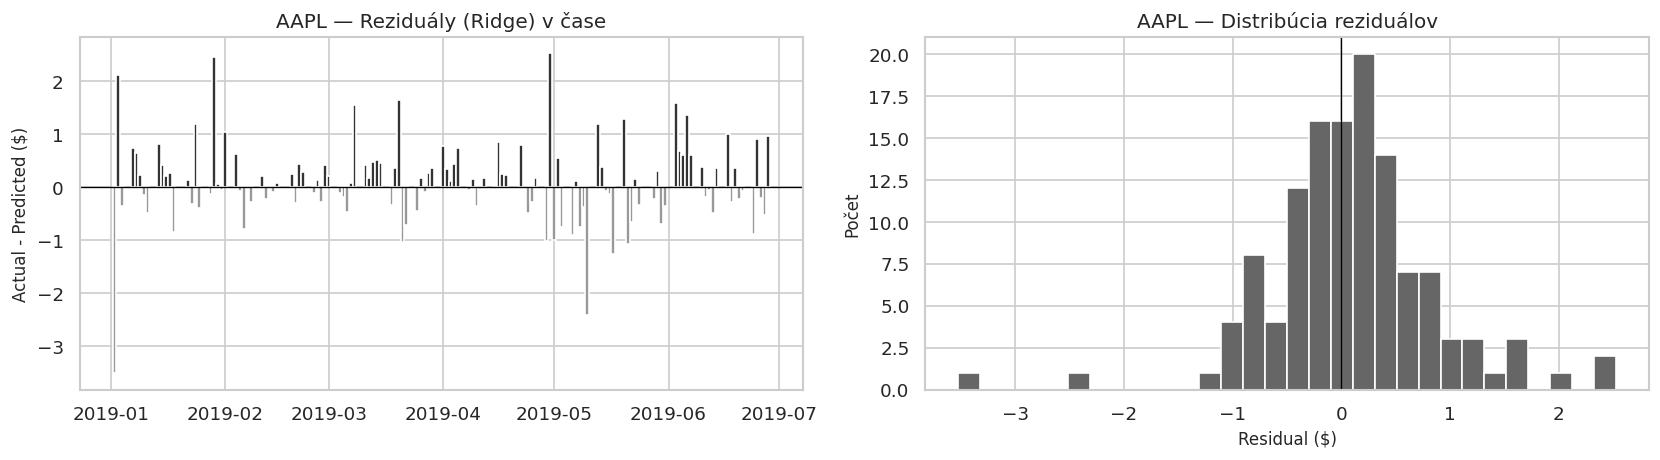

Mean residual: 0.0910 (blízko 0 = nebiasovaný)
Std residual:  0.7818


In [ ]:
# Analyza rezidualov pre najlepsi model (na priklade prveho tickeru)

res = results[0]
ticker = res['Ticker']
dates = pd.to_datetime(res['test_dates'])

# Pouzijeme Ridge ako nas hlavny model
residuals = res['y_test'] - res['ridge_pred']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

# Residualy v case
ax1.bar(dates, residuals, color=['#333' if r >= 0 else '#999' for r in residuals], width=1)
ax1.axhline(0, color='black', linewidth=0.8)
ax1.set_title(f'{ticker} — Reziduály (Ridge) v čase')
ax1.set_ylabel('Actual - Predicted ($)')
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

# Histogram rezidualov
ax2.hist(residuals, bins=30, color='#666', edgecolor='white')
ax2.axvline(0, color='black', linewidth=0.8)
ax2.set_title(f'{ticker} — Distribúcia reziduálov')
ax2.set_xlabel('Residual ($)')
ax2.set_ylabel('Počet')

plt.tight_layout()
plt.show()

print(f'Mean residual: {residuals.mean():.4f} (blízko 0 = nebiasovaný)')
print(f'Std residual:  {residuals.std():.4f}')


## Prečo LSTM?

Klasické modely pracujú s features z jedného dňa. LSTM dostane sekvenciu posledných N dní a môže zachytiť momentum a dlhšie vzory.


In [ ]:
# Use Case

# Part 1: Print available tickers
print("Dostupné tickery:")
available_tickers = sorted(df['Ticker'].unique().tolist())
for i, t in enumerate(available_tickers):
    print(f"  {t}", end="")
    if (i + 1) % 10 == 0:
        print()
print(f"\n\nCelkom: {len(available_tickers)} tickerov\n")

# Part 2: Select ticker
SELECTED_TICKER = 'AAPL'

# Part 3: Select prediction horizon (in trading days)
PREDICT_DAYS = 1

# Date from which we predict
PREDICT_FROM = '2019-03-25'

# --- Computation ---
ticker_data = df[df['Ticker'] == SELECTED_TICKER].sort_values('Date').copy()

# Find the closest trading day to our requested date
ticker_data['Date'] = pd.to_datetime(ticker_data['Date'])
mask = ticker_data['Date'] >= PREDICT_FROM
if mask.sum() == 0:
    print(f"Žiadne dáta po {PREDICT_FROM} pre {SELECTED_TICKER}")
else:
    start_idx = ticker_data[mask].index[0]
    start_pos = ticker_data.index.get_loc(start_idx)

    if start_pos + PREDICT_DAYS >= len(ticker_data):
        print(f"Nedostatok dát na predikciu {PREDICT_DAYS} dní dopredu od {PREDICT_FROM}")
    else:
        start_row = ticker_data.iloc[start_pos]
        target_row = ticker_data.iloc[start_pos + PREDICT_DAYS]

        start_date = start_row['Date']
        target_date = target_row['Date']
        price_today = start_row['Close']
        price_actual = target_row['Close']

        # Train model on data BEFORE start_date
        train_data = prepare_features(
            ticker_data[ticker_data['Date'] < start_date].copy()
        )
        # Override target to match our horizon
        raw = ticker_data[ticker_data['Date'] < start_date].sort_values('Date').copy()
        raw['Close_Lag1'] = raw['Close'].shift(1)
        raw['Close_Lag2'] = raw['Close'].shift(2)
        raw['Close_Lag3'] = raw['Close'].shift(3)
        raw['Volume_Lag1'] = raw['Volume'].shift(1)
        raw['SMA_5'] = raw['Close'].rolling(5).mean()
        raw['SMA_20'] = raw['Close'].rolling(20).mean()
        raw['Daily_Range'] = raw['High'] - raw['Low']
        raw['Target'] = raw['Close'].shift(-PREDICT_DAYS)
        raw = raw.dropna()

        if len(raw) < 50:
            print(f"Nedostatok trénovacích dát ({len(raw)} riadkov)")
        else:
            X_tr = raw[FEATURE_COLS].values
            y_tr = raw['Target'].values

            model = Ridge(alpha=1.0)
            model.fit(X_tr, y_tr)

            # Build features for the prediction day
            recent = ticker_data[ticker_data['Date'] <= start_date].tail(20).copy()
            pred_row = recent.iloc[-1]
            features = {
                'Open': pred_row['Open'],
                'High': pred_row['High'],
                'Low': pred_row['Low'],
                'Close': pred_row['Close'],
                'Volume': pred_row['Volume'],
                'Close_Lag1': recent.iloc[-2]['Close'],
                'Close_Lag2': recent.iloc[-3]['Close'],
                'Close_Lag3': recent.iloc[-4]['Close'],
                'Volume_Lag1': recent.iloc[-2]['Volume'],
                'SMA_5': recent.tail(5)['Close'].mean(),
                'SMA_20': recent.tail(20)['Close'].mean(),
                'Daily_Range': pred_row['High'] - pred_row['Low'],
            }
            X_pred = np.array([[features[c] for c in FEATURE_COLS]])
            price_predicted = model.predict(X_pred)[0]

            # Output
            print(f"{'='*55}")
            print(f"  Ticker:           {SELECTED_TICKER}")
            print(f"  Horizont:         {PREDICT_DAYS} obchodných dní")
            print(f"{'='*55}")
            print(f"  Deň predikcie:    {start_date.date()}")
            print(f"  Cena v ten deň:   ${price_today:.2f}")
            print(f"{'='*55}")
            print(f"  Cieľový deň:      {target_date.date()}")
            print(f"  Skutočná cena:    ${price_actual:.2f}")
            print(f"  Predikovaná cena: ${price_predicted:.2f}")
            print(f"{'='*55}")
            error = abs(price_predicted - price_actual)
            error_pct = error / price_actual * 100
            print(f"  Chyba:            ${error:.2f} ({error_pct:.2f}%)")
            direction_ok = (price_predicted > price_today) == (price_actual > price_today)
            print(f"  Smer správny:     {'ÁNO' if direction_ok else 'NIE'}")

Dostupné tickery:
  AAPL  ABNB  ADBE  ADI  ADP  ADSK  AEP  AMAT  AMD  AMGN
  AMZN  APP  ASML  AVGO  AZN  BIIB  BKNG  BKR  CCEP  CDNS
  CDW  CEG  CHTR  CMCSA  COIN  COST  CPRT  CRWD  CSGP  CTAS
  CTSH  DASH  DDOG  DLTR  DXCM  EA  EXC  FANG  FAST  FTNT
  GFS  GILD  GOOG  GOOGL  HON  IDXX  INTC  INTU  ISRG  KDP
  KHC  KLAC  LIN  LRCX  LULU  MAR  MCHP  MDB  MDLZ  MELI
  META  MNST  MRNA  MRVL  MSFT  MU  NFLX  NVDA  NXPI  ODFL
  ON  ORLY  PANW  PAYX  PCAR  PDD  PEP  PLTR  PYPL  QCOM
  REGN  ROP  ROST  SBUX  SMCI  SNPS  TEAM  TMUS  TSLA  TTD
  TTWO  TXN  VRSK  VRTX  WBD  WDAY  XEL  ZS

Celkom: 98 tickerov

  Ticker:           AAPL
  Horizont:         1 obchodných dní
  Deň predikcie:    2019-03-25
  Cena v ten deň:   $45.02
  Cieľový deň:      2019-03-26
  Skutočná cena:    $44.55
  Predikovaná cena: $45.05
  Chyba:            $0.50 (1.13%)
  Smer správny:     NIE


# LSTM — Deep Learning

LSTM potrebuje viac dát ako klasické modely, preto rozširujeme tréningové obdobie na 2000–2018 (~4 770 obchodných dní). Test ostáva jan–jun 2019.

Otestujeme 9 rôznych konfigurácií — lookback, units, dropout, tréningové obdobia.


In [ ]:
# Imports pre LSTM
!pip install tensorflow
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import MinMaxScaler

# Reprodukovateľnosť
np.random.seed(42)
tf.random.set_seed(42)

print(f'TensorFlow: {tf.__version__}')


TensorFlow: 2.19.0


In [ ]:
# LSTM tréningové obdobie — dlhšie než pre klasické modely
# LSTM potrebuje tisíce sekvencií, klasická regresia stačí s 750 dňami
LSTM_TRAIN_START = '2000-01-01'
LSTM_TRAIN_END   = '2018-12-31'  # končíme pred test obdobím

# Porovnanie objemu dát
_tmp = df[df['Ticker'] == 'AAPL']
_reg_days = len(_tmp[(_tmp['Date'] >= TRAIN_START) & (_tmp['Date'] <= TRAIN_END)])
_lstm_days = len(_tmp[(_tmp['Date'] >= LSTM_TRAIN_START) & (_tmp['Date'] <= LSTM_TRAIN_END)])

print(f'Klasická regresia: {TRAIN_START} → {TRAIN_END}  ({_reg_days} dní)')
print(f'LSTM tréning:      {LSTM_TRAIN_START} → {LSTM_TRAIN_END}  ({_lstm_days} dní)')
print(f'LSTM má {_lstm_days/_reg_days:.1f}× viac tréningových dát')
print(f'Test obdobie:      {TEST_START} → {TEST_END}  (rovnaké pre oba)')


Klasická regresia: 2016-01-01 → 2018-12-31  (754 dní)
LSTM tréning:      2000-01-01 → 2018-12-31  (4779 dní)
LSTM má 6.3× viac tréningových dát
Test obdobie:      2019-01-01 → 2019-06-30  (rovnaké pre oba)


In [ ]:
def create_sequences(data, target, look_back):
    """
    Transformuje 2D dáta na 3D sekvencie potrebné pre LSTM.

    data:   (n_samples, n_features)
    target: (n_samples,)
    returns:
      X: (n_sequences, look_back, n_features) - posledných look_back dni
      y: (n_sequences,) - cena v nasledujúci deň
    """
    X, y = [], []
    for i in range(len(data) - look_back):
        X.append(data[i:i + look_back])
        y.append(target[i + look_back])
    return np.array(X), np.array(y)


# Test na malych datach aby sme videli co funkcia robi
example_data = np.array([[1], [2], [3], [4], [5], [6]])
example_target = np.array([10, 20, 30, 40, 50, 60])
X_ex, y_ex = create_sequences(example_data, example_target, look_back=3)
print('Ukážka ako create_sequences funguje (look_back=3):')
print(f'Vstupné dáta: {example_data.flatten()}')
print(f'Vytvorené sekvencie:')
for i in range(len(X_ex)):
    print(f'  X[{i}] = {X_ex[i].flatten()} → y[{i}] = {y_ex[i]}')


Ukážka ako create_sequences funguje (look_back=3):
Vstupné dáta: [1 2 3 4 5 6]
Vytvorené sekvencie:
  X[0] = [1 2 3] → y[0] = 40
  X[1] = [2 3 4] → y[1] = 50
  X[2] = [3 4 5] → y[2] = 60


## Experiment 1 — Basic LSTM

Začneme jednoduchým univariátnym modelom: len Close cena, lookback = 10, 1 LSTM vrstva.


In [ ]:
# Basic LSTM - univariate, 10-day lookback, 1 LSTM layer
# Testujeme na AAPL (dá sa zmeniť)

TICKER = 'AAPL'
LOOK_BACK = 10

# Priprava dat
ticker_df = df[df['Ticker'] == TICKER].copy().sort_values('Date')
train_df = ticker_df[(ticker_df['Date'] >= LSTM_TRAIN_START) & (ticker_df['Date'] <= LSTM_TRAIN_END)]
test_df  = ticker_df[(ticker_df['Date'] >= TEST_START) & (ticker_df['Date'] <= TEST_END)]

# Iba Close cena
train_close = train_df['Close'].values.reshape(-1, 1)
test_close  = test_df['Close'].values.reshape(-1, 1)

# Skalovanie (MinMax 0-1) — nutné pre LSTM
scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(train_close)
test_scaled  = scaler.transform(test_close)

# Vytvorenie sekvencii
X_train, y_train = create_sequences(train_scaled, train_scaled.flatten(), LOOK_BACK)
X_test,  y_test  = create_sequences(test_scaled,  test_scaled.flatten(),  LOOK_BACK)

print(f'Ticker: {TICKER}')
print(f'Train sekvencie: {X_train.shape} → {y_train.shape}')
print(f'Test sekvencie:  {X_test.shape} → {y_test.shape}')

# Model
basic_model = Sequential([
    Input(shape=(LOOK_BACK, 1)),
    LSTM(units=20),
    Dense(units=1)
])
basic_model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])
basic_model.summary()


Ticker: AAPL
Train sekvencie: (4769, 10, 1) → (4769,)
Test sekvencie:  (114, 10, 1) → (114,)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 20)             │         1,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,781 (6.96 KB)

 Trainable params: 1,781 (6.96 KB)

 Non-trainable params: 0 (0.00 B)

Trénovanie dokončené po 6 epochách

Basic LSTM vysledky na AAPL:
  R²   = 0.7602
  RMSE = 1.7509


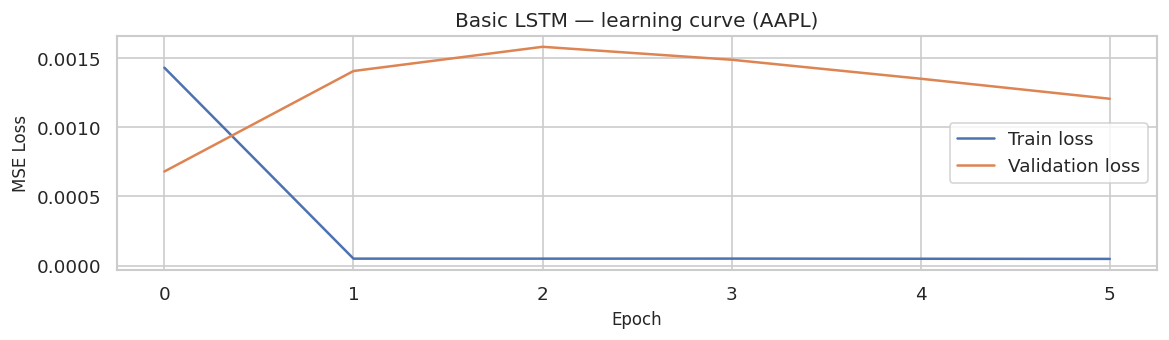

In [ ]:
# Trenovanie basic LSTM
history = basic_model.fit(
    X_train, y_train,
    epochs=30, batch_size=16,
    validation_split=0.1,
    callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)],
    verbose=0
)
print(f'Trénovanie dokončené po {len(history.history["loss"])} epochách')

# Predikcia a spatne skalovanie
basic_pred_scaled = basic_model.predict(X_test, verbose=0).flatten()
basic_pred = scaler.inverse_transform(basic_pred_scaled.reshape(-1, 1)).flatten()
basic_true = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

# Metriky
basic_r2 = r2_score(basic_true, basic_pred)
basic_rmse = np.sqrt(mean_squared_error(basic_true, basic_pred))

print(f'\nBasic LSTM vysledky na {TICKER}:')
print(f'  R²   = {basic_r2:.4f}')
print(f'  RMSE = {basic_rmse:.4f}')

# Graf - learning curve
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(history.history['loss'], label='Train loss')
ax.plot(history.history['val_loss'], label='Validation loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.set_title(f'Basic LSTM — learning curve ({TICKER})')
ax.legend()
plt.tight_layout()
plt.show()


## Experiment 2 — Rôzne lookback okná (10 / 20 / 30 dní)


In [ ]:
# Helper funkcia pre tréning LSTM s nastavitelnymi parametrami
def train_univariate_lstm(ticker, look_back, units=20, epochs=30, verbose=0):
    """Natrénuje univariátny LSTM a vráti metriky + predikcie."""
    ticker_df = df[df['Ticker'] == ticker].copy().sort_values('Date')
    train_df = ticker_df[(ticker_df['Date'] >= LSTM_TRAIN_START) & (ticker_df['Date'] <= LSTM_TRAIN_END)]
    test_df  = ticker_df[(ticker_df['Date'] >= TEST_START) & (ticker_df['Date'] <= TEST_END)]

    train_close = train_df['Close'].values.reshape(-1, 1)
    test_close  = test_df['Close'].values.reshape(-1, 1)

    scaler = MinMaxScaler((0, 1))
    train_scaled = scaler.fit_transform(train_close)
    test_scaled  = scaler.transform(test_close)

    X_tr, y_tr = create_sequences(train_scaled, train_scaled.flatten(), look_back)
    X_te, y_te = create_sequences(test_scaled,  test_scaled.flatten(),  look_back)

    if len(X_tr) < 20 or len(X_te) < 5:
        return None

    model = Sequential([
        Input(shape=(look_back, 1)),
        LSTM(units=units),
        Dense(1)
    ])
    model.compile(optimizer=Adam(0.001), loss='mse')
    model.fit(X_tr, y_tr, epochs=epochs, batch_size=16, validation_split=0.1,
              callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)],
              verbose=verbose)

    pred = scaler.inverse_transform(model.predict(X_te, verbose=0)).flatten()
    true = scaler.inverse_transform(y_te.reshape(-1, 1)).flatten()
    dates = test_df['Date'].values[look_back:]

    return {
        'r2': r2_score(true, pred),
        'rmse': np.sqrt(mean_squared_error(true, pred)),
        'pred': pred, 'true': true, 'dates': dates,
        'look_back': look_back,
    }


# Experiment: porovnanie lookback okien
LOOKBACKS = [10, 20, 30]
lookback_results = {}

print(f'Porovnanie lookback okien na {TICKER}:\n')
print(f'{"Lookback":<12} {"R²":>8} {"RMSE":>10}')
print('-' * 32)
for lb in LOOKBACKS:
    tf.keras.backend.clear_session()
    r = train_univariate_lstm(TICKER, look_back=lb)
    if r:
        lookback_results[lb] = r
        print(f'{lb:<12} {r["r2"]:>8.4f} {r["rmse"]:>10.4f}')

best_lb = max(lookback_results, key=lambda k: lookback_results[k]['r2'])
print(f'\nNajlepší lookback: {best_lb}')


Porovnanie lookback okien na AAPL:

Lookback           R²       RMSE
--------------------------------
10             0.5680     2.3503


20             0.8721     1.0485
30             0.6930     1.4917

Najlepší lookback: 20


## Experiment 3 — Multivariate LSTM

Pridávame Volume, SMA_5, SMA_20, Daily_Range — zistíme, či viac features pomôže.


In [ ]:
# Multivariate LSTM - Close + Volume + SMA_5 + SMA_20 + Daily_Range
MV_FEATURES = ['Close', 'Volume', 'SMA_5', 'SMA_20', 'Daily_Range']

def train_multivariate_lstm(ticker, look_back, features, units=30, stacked=False, epochs=30):
    """Natrénuje multivariate LSTM."""
    ticker_df = df[df['Ticker'] == ticker].copy().sort_values('Date')
    # Pridat SMA a Daily_Range
    ticker_df['SMA_5']  = ticker_df['Close'].rolling(5).mean()
    ticker_df['SMA_20'] = ticker_df['Close'].rolling(20).mean()
    ticker_df['Daily_Range'] = ticker_df['High'] - ticker_df['Low']
    ticker_df = ticker_df.dropna()

    train_df = ticker_df[(ticker_df['Date'] >= LSTM_TRAIN_START) & (ticker_df['Date'] <= LSTM_TRAIN_END)]
    test_df  = ticker_df[(ticker_df['Date'] >= TEST_START) & (ticker_df['Date'] <= TEST_END)]

    # Skalovanie features a targetu separately
    scaler_X = MinMaxScaler((0, 1))
    scaler_y = MinMaxScaler((0, 1))

    X_tr_raw = train_df[features].values
    X_te_raw = test_df[features].values
    y_tr_raw = train_df['Close'].values.reshape(-1, 1)
    y_te_raw = test_df['Close'].values.reshape(-1, 1)

    X_tr_sc = scaler_X.fit_transform(X_tr_raw)
    X_te_sc = scaler_X.transform(X_te_raw)
    y_tr_sc = scaler_y.fit_transform(y_tr_raw).flatten()
    y_te_sc = scaler_y.transform(y_te_raw).flatten()

    X_tr, y_tr = create_sequences(X_tr_sc, y_tr_sc, look_back)
    X_te, y_te = create_sequences(X_te_sc, y_te_sc, look_back)

    if len(X_tr) < 20 or len(X_te) < 5:
        return None

    # Model
    model = Sequential()
    model.add(Input(shape=(look_back, len(features))))
    if stacked:
        model.add(LSTM(units, return_sequences=True))
        model.add(Dropout(0.2))
        model.add(LSTM(units // 2))
    else:
        model.add(LSTM(units))
    model.add(Dropout(0.2))
    model.add(Dense(1))
    model.compile(optimizer=Adam(0.001), loss='mse')
    model.fit(X_tr, y_tr, epochs=epochs, batch_size=16, validation_split=0.1,
              callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)],
              verbose=0)

    pred = scaler_y.inverse_transform(model.predict(X_te, verbose=0)).flatten()
    true = scaler_y.inverse_transform(y_te.reshape(-1, 1)).flatten()
    dates = test_df['Date'].values[look_back:]

    return {
        'r2': r2_score(true, pred),
        'rmse': np.sqrt(mean_squared_error(true, pred)),
        'pred': pred, 'true': true, 'dates': dates,
    }


# Porovnanie: univariate (len Close) vs multivariate (Close + extra)
print(f'Univariate vs Multivariate LSTM na {TICKER} (lookback={best_lb}):\n')

uni_r = lookback_results[best_lb]
print(f'  Univariate  (1 feature):            R²={uni_r["r2"]:.4f}  RMSE={uni_r["rmse"]:.4f}')

mv_r = train_multivariate_lstm(TICKER, best_lb, MV_FEATURES)
print(f'  Multivariate ({len(MV_FEATURES)} features):           R²={mv_r["r2"]:.4f}  RMSE={mv_r["rmse"]:.4f}')

if mv_r['r2'] > uni_r['r2']:
    print(f'\n  → Multivariate pomohol (viac informácií = lepšia predikcia)')
else:
    print(f'\n  → Multivariate nepomohol (extra features pridali šum, podobne ako u referenčného tímu)')


Univariate vs Multivariate LSTM na AAPL (lookback=20):

  Univariate  (1 feature):            R²=0.8721  RMSE=1.0485
  Multivariate (5 features):           R²=0.7118  RMSE=1.5740

  → Multivariate nepomohol (extra features pridali šum, podobne ako u referenčného tímu)


## Experiment 4 — Stacked LSTM (2 vrstvy)


In [ ]:
# Stacked LSTM experiment
print(f'Single vs Stacked LSTM na {TICKER} (lookback={best_lb}):\n')

single_r = train_multivariate_lstm(TICKER, best_lb, MV_FEATURES, stacked=False)
print(f'  Single LSTM (1 layer, 30 units):         R²={single_r["r2"]:.4f}')

stacked_r = train_multivariate_lstm(TICKER, best_lb, MV_FEATURES, stacked=True)
print(f'  Stacked LSTM (30 + 15 units):            R²={stacked_r["r2"]:.4f}')

if stacked_r['r2'] > single_r['r2']:
    print(f'\n  → Stacked pomohol')
    BEST_LSTM = stacked_r
    BEST_LSTM_CONFIG = 'Stacked LSTM (30+15 units, multivariate)'
else:
    print(f'\n  → Single stačí (stacked overfituje)')
    BEST_LSTM = single_r
    BEST_LSTM_CONFIG = 'Single LSTM (30 units, multivariate)'

print(f'\nVíťazná konfigurácia: {BEST_LSTM_CONFIG}')


Single vs Stacked LSTM na AAPL (lookback=20):

  Single LSTM (1 layer, 30 units):         R²=0.5016
  Stacked LSTM (30 + 15 units):            R²=-0.5611

  → Single stačí (stacked overfituje)

Víťazná konfigurácia: Single LSTM (30 units, multivariate)


## Experiment 5 — Počet LSTM units (5 / 10 / 20 / 50 / 100)


In [ ]:
# Experiment 5: Grid search cez LSTM units
UNITS_GRID = [5, 10, 20, 50, 100]
FIXED_LOOKBACK = 10

print(f'Testujeme rôzne počty units na {TICKER} (lookback={FIXED_LOOKBACK}):\n')
print(f'{"Units":<10} {"R²":>10} {"RMSE":>12} {"Verdikt":<30}')
print('-' * 62)

units_results = {}
for u in UNITS_GRID:
    r = train_univariate_lstm(TICKER, look_back=FIXED_LOOKBACK, units=u, epochs=30)
    if r is None:
        continue
    units_results[u] = r

    # Heuristika pre verdikt
    if r['r2'] < 0:
        verdict = "model nefunguje"
    elif r['r2'] < 0.5:
        verdict = "slabé"
    elif r['r2'] < 0.8:
        verdict = "OK"
    elif r['r2'] < 0.95:
        verdict = "dobré"
    else:
        verdict = "výborné"

    print(f'{u:<10} {r["r2"]:>10.4f} {r["rmse"]:>12.4f} {verdict:<30}')

best_units = max(units_results, key=lambda k: units_results[k]['r2'])
print(f'\nNajlepší počet units: {best_units} (R²={units_results[best_units]["r2"]:.4f})')


Testujeme rôzne počty units na AAPL (lookback=10):

Units              R²         RMSE Verdikt                       
--------------------------------------------------------------
5              0.3412       2.9024 slabé                         
10             0.7198       1.8927 OK                            
20             0.7977       1.6082 OK                            
50             0.9599       0.7157 výborné                       
100            0.9578       0.7345 výborné                       

Najlepší počet units: 50 (R²=0.9599)


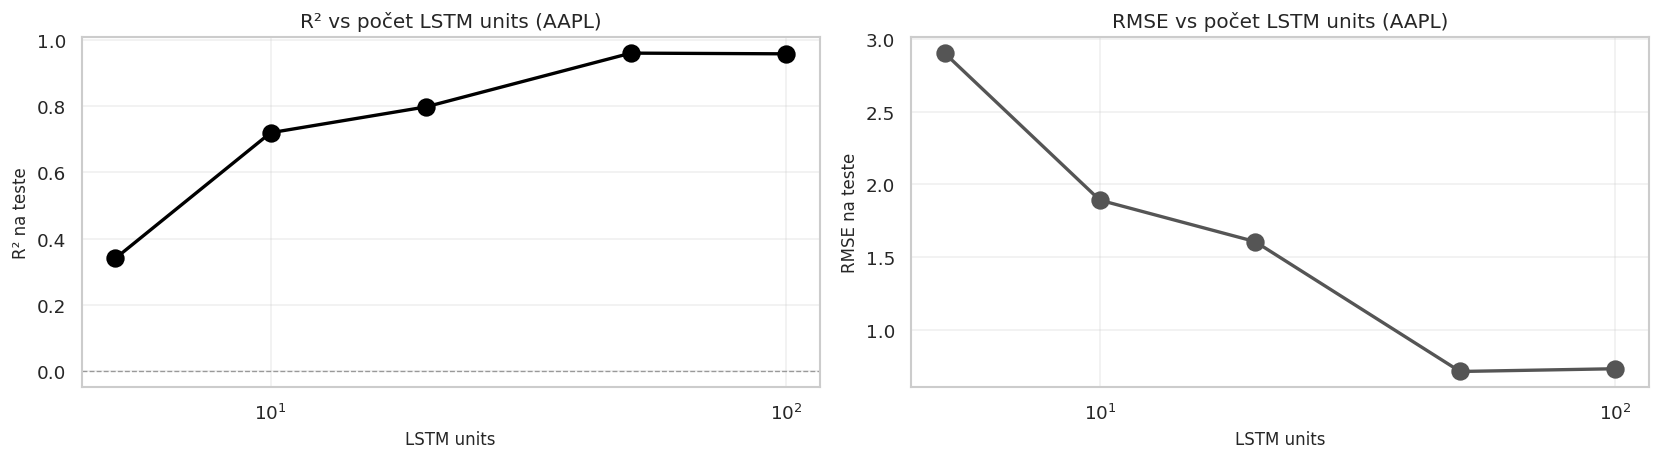

Interpretácia:
  - Príliš malé (5) alebo príliš veľké (100) units sú horšie ako stredné hodnoty
  - Financné dáta majú nízky signal-to-noise ratio — väčší model memorizuje šum


In [ ]:
# Vizualizacia - ako sa meni R2 s poctom units
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

units_list = list(units_results.keys())
r2_list = [units_results[u]['r2'] for u in units_list]
rmse_list = [units_results[u]['rmse'] for u in units_list]

ax1.plot(units_list, r2_list, 'o-', color='black', linewidth=2, markersize=10)
ax1.axhline(0, color='#999', linestyle='--', linewidth=0.8)
ax1.set_xlabel('LSTM units')
ax1.set_ylabel('R² na teste')
ax1.set_title(f'R² vs počet LSTM units ({TICKER})')
ax1.set_xscale('log')
ax1.grid(True, alpha=0.3)

ax2.plot(units_list, rmse_list, 'o-', color='#555', linewidth=2, markersize=10)
ax2.set_xlabel('LSTM units')
ax2.set_ylabel('RMSE na teste')
ax2.set_title(f'RMSE vs počet LSTM units ({TICKER})')
ax2.set_xscale('log')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Interpretácia:")
print("  - Príliš malé (5) alebo príliš veľké (100) units sú horšie ako stredné hodnoty")
print("  - Financné dáta majú nízky signal-to-noise ratio — väčší model memorizuje šum")


## Experiment 6 — Rozšírený lookback (5 / 10 / 20 / 30 / 60 / 90 dní)


In [ ]:
# Experiment 6: Extended lookback
LOOKBACK_GRID = [5, 10, 20, 30, 60, 90]
FIXED_UNITS = best_units  # pouzime najlepsi vysledok z Exp 5

print(f'Extended lookback sweep na {TICKER} (units={FIXED_UNITS}):\n')
print(f'{"Lookback":<12} {"R²":>10} {"RMSE":>12}')
print('-' * 36)

lb_ext_results = {}
for lb in LOOKBACK_GRID:
    r = train_univariate_lstm(TICKER, look_back=lb, units=FIXED_UNITS, epochs=30)
    if r is None:
        print(f'{lb:<12} nedostatok dát')
        continue
    lb_ext_results[lb] = r
    print(f'{lb:<12} {r["r2"]:>10.4f} {r["rmse"]:>12.4f}')

best_lb_ext = max(lb_ext_results, key=lambda k: lb_ext_results[k]['r2'])
print(f'\nNajlepší lookback: {best_lb_ext} (R²={lb_ext_results[best_lb_ext]["r2"]:.4f})')


Extended lookback sweep na AAPL (units=50):

Lookback             R²         RMSE
------------------------------------
5                0.8788       1.3407
10               0.9627       0.6905
20               0.9389       0.7249
30               0.9290       0.7173
60               0.7573       1.0677
90               0.7227       1.0119

Najlepší lookback: 10 (R²=0.9627)


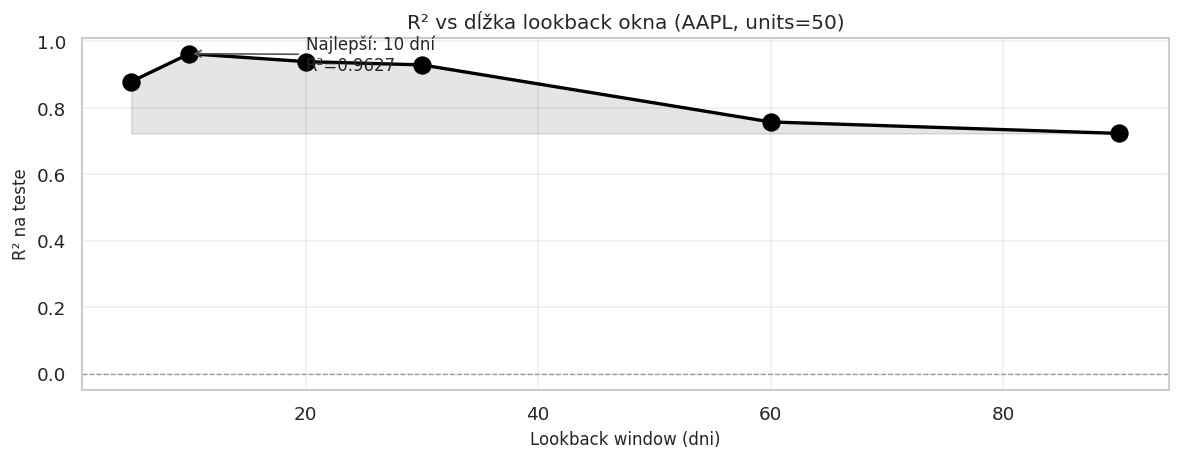

In [ ]:
# Vizualizacia lookback sweep
fig, ax = plt.subplots(figsize=(10, 4))
lbs = list(lb_ext_results.keys())
r2s = [lb_ext_results[lb]['r2'] for lb in lbs]

ax.plot(lbs, r2s, 'o-', color='black', linewidth=2, markersize=10)
ax.axhline(0, color='#999', linestyle='--', linewidth=0.8)
ax.fill_between(lbs, r2s, min(r2s), alpha=0.1, color='black')
ax.set_xlabel('Lookback window (dni)')
ax.set_ylabel('R² na teste')
ax.set_title(f'R² vs dĺžka lookback okna ({TICKER}, units={FIXED_UNITS})')
ax.grid(True, alpha=0.3)

# Anotacia najlepsieho
best_r2 = lb_ext_results[best_lb_ext]['r2']
ax.annotate(f'Najlepší: {best_lb_ext} dní\nR²={best_r2:.4f}',
            xy=(best_lb_ext, best_r2), xytext=(best_lb_ext + 10, best_r2 - 0.05),
            fontsize=10, arrowprops=dict(arrowstyle='->', color='#555'))

plt.tight_layout()
plt.show()


## Experiment 7 — Dropout (0.0 / 0.1 / 0.2 / 0.3 / 0.5)


In [ ]:
def train_lstm_with_dropout(ticker, look_back, units, dropout_rate, epochs=30):
    """LSTM s konfigurovatelnou dropout hodnotou."""
    ticker_df = df[df['Ticker'] == ticker].copy().sort_values('Date')
    train_df = ticker_df[(ticker_df['Date'] >= LSTM_TRAIN_START) & (ticker_df['Date'] <= LSTM_TRAIN_END)]
    test_df  = ticker_df[(ticker_df['Date'] >= TEST_START) & (ticker_df['Date'] <= TEST_END)]

    train_close = train_df['Close'].values.reshape(-1, 1)
    test_close  = test_df['Close'].values.reshape(-1, 1)

    scaler = MinMaxScaler((0, 1))
    train_scaled = scaler.fit_transform(train_close)
    test_scaled  = scaler.transform(test_close)

    X_tr, y_tr = create_sequences(train_scaled, train_scaled.flatten(), look_back)
    X_te, y_te = create_sequences(test_scaled,  test_scaled.flatten(),  look_back)

    if len(X_tr) < 20 or len(X_te) < 5:
        return None

    model = Sequential([
        Input(shape=(look_back, 1)),
        LSTM(units=units),
        Dropout(dropout_rate),
        Dense(1)
    ])
    model.compile(optimizer=Adam(0.001), loss='mse')
    model.fit(X_tr, y_tr, epochs=epochs, batch_size=16, validation_split=0.1,
              callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)],
              verbose=0)

    pred = scaler.inverse_transform(model.predict(X_te, verbose=0)).flatten()
    true = scaler.inverse_transform(y_te.reshape(-1, 1)).flatten()
    return {'r2': r2_score(true, pred), 'rmse': np.sqrt(mean_squared_error(true, pred))}


DROPOUT_GRID = [0.0, 0.1, 0.2, 0.3, 0.5]
print(f'Dropout sensitivity na {TICKER} (lookback={best_lb_ext}, units={best_units}):\n')
print(f'{"Dropout":<10} {"R²":>10} {"RMSE":>12}')
print('-' * 34)

dropout_results = {}
for d in DROPOUT_GRID:
    r = train_lstm_with_dropout(TICKER, best_lb_ext, best_units, d)
    if r:
        dropout_results[d] = r
        print(f'{d:<10} {r["r2"]:>10.4f} {r["rmse"]:>12.4f}')

best_dropout = max(dropout_results, key=lambda k: dropout_results[k]['r2'])
print(f'\nNajlepší dropout: {best_dropout}')


Dropout sensitivity na AAPL (lookback=10, units=50):

Dropout            R²         RMSE
----------------------------------
0.0            0.9547       0.7609
0.1            0.9361       0.9041
0.2            0.9300       0.9460
0.3            0.7913       1.6334
0.5            0.8552       1.3604

Najlepší dropout: 0.0


## Experiment 8 — Rôzne tréningové obdobia

Testujeme 5 kombinácií tréning/predikcia — od krátkych stabilných periód po dlhé obdobia zahŕňajúce dot-com, GFC aj COVID.


In [ ]:
def train_lstm_custom_period(ticker, train_start, train_end, test_start, test_end,
                              look_back=10, units=20, epochs=30):
    """LSTM s konfigurovatelnym obdobim."""
    ticker_df = df[df['Ticker'] == ticker].copy().sort_values('Date')
    train_df = ticker_df[(ticker_df['Date'] >= train_start) & (ticker_df['Date'] <= train_end)]
    test_df  = ticker_df[(ticker_df['Date'] >= test_start) & (ticker_df['Date'] <= test_end)]

    if len(train_df) < 100 or len(test_df) < 5:
        return None

    scaler = MinMaxScaler((0, 1))
    train_scaled = scaler.fit_transform(train_df['Close'].values.reshape(-1, 1))
    test_scaled  = scaler.transform(test_df['Close'].values.reshape(-1, 1))

    X_tr, y_tr = create_sequences(train_scaled, train_scaled.flatten(), look_back)
    X_te, y_te = create_sequences(test_scaled,  test_scaled.flatten(),  look_back)

    if len(X_tr) < 20 or len(X_te) < 1:
        return None

    model = Sequential([
        Input(shape=(look_back, 1)),
        LSTM(units=units),
        Dropout(0.2),
        Dense(1)
    ])
    model.compile(optimizer=Adam(0.001), loss='mse')
    model.fit(X_tr, y_tr, epochs=epochs, batch_size=16, validation_split=0.1,
              callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)],
              verbose=0)

    pred = scaler.inverse_transform(model.predict(X_te, verbose=0)).flatten()
    true = scaler.inverse_transform(y_te.reshape(-1, 1)).flatten()
    dates = test_df['Date'].values[look_back:]

    return {
        'r2': r2_score(true, pred),
        'rmse': np.sqrt(mean_squared_error(true, pred)),
        'pred': pred, 'true': true, 'dates': dates,
        'train_days': len(train_df), 'test_days': len(test_df),
    }


# Konfigurácie - 5 kombinácií
PERIOD_CONFIGS = [
    ('A', '2016-01-01', '2018-12-31', '2019-01-01', '2019-01-18',
     '3 roky tréning → 13 dní predikcie'),
    ('B', '2016-01-01', '2018-12-31', '2019-01-01', '2019-06-30',
     '3 roky tréning → 6 mesiacov predikcie'),
    ('C', '2000-01-01', '2019-12-31', '2020-01-01', '2020-01-18',
     '20 rokov tréning → 12 dní predikcie'),
    ('D', '2000-01-01', '2019-12-31', '2020-01-01', '2020-06-30',
     '20 rokov tréning → 6 mesiacov predikcie (obsahuje COVID!)'),
    ('E', '2010-01-01', '2014-12-31', '2015-01-01', '2015-03-31',
     '5 rokov tréning → 3 mesiace predikcie (pokojné obdobie)'),
    ('F', '2000-01-01', '2018-12-31', '2019-01-01', '2019-06-30',
     '19 rokov tréning → 6 mesiacov predikcie (neobsahuje COVID)'),
]

print(f'Training period experiment na {TICKER}:\n')
print(f'{"#":<3} {"Train dni":>10} {"Test dni":>10} {"R²":>10} {"RMSE":>12}  Popis')
print('-' * 100)

period_results = {}
for label, tr_s, tr_e, te_s, te_e, desc in PERIOD_CONFIGS:
    r = train_lstm_custom_period(TICKER, tr_s, tr_e, te_s, te_e, look_back=10, units=20)
    if r is None:
        print(f'{label:<3}  nedostatok dát')
        continue
    period_results[label] = {**r, 'desc': desc, 'train_period': f'{tr_s}–{tr_e}',
                              'test_period': f'{te_s}–{te_e}'}
    print(f'{label:<3} {r["train_days"]:>10} {r["test_days"]:>10} {r["r2"]:>10.4f} {r["rmse"]:>12.4f}  {desc}')


Training period experiment na AAPL:

#    Train dni   Test dni         R²         RMSE  Popis
----------------------------------------------------------------------------------------------------
A          754         13   -28.1985       0.9710  3 roky tréning → 13 dní predikcie
B          754        124     0.7861       1.6539  3 roky tréning → 6 mesiacov predikcie
C         5031         12   -88.6662       3.9771  20 rokov tréning → 12 dní predikcie
D         5031        125     0.6966       4.4727  20 rokov tréning → 6 mesiacov predikcie (obsahuje COVID!)
E         1258         61     0.6487       0.8705  5 rokov tréning → 3 mesiace predikcie (pokojné obdobie)
F         4779        124     0.8629       1.3241  19 rokov tréning → 6 mesiacov predikcie (neobsahuje COVID)


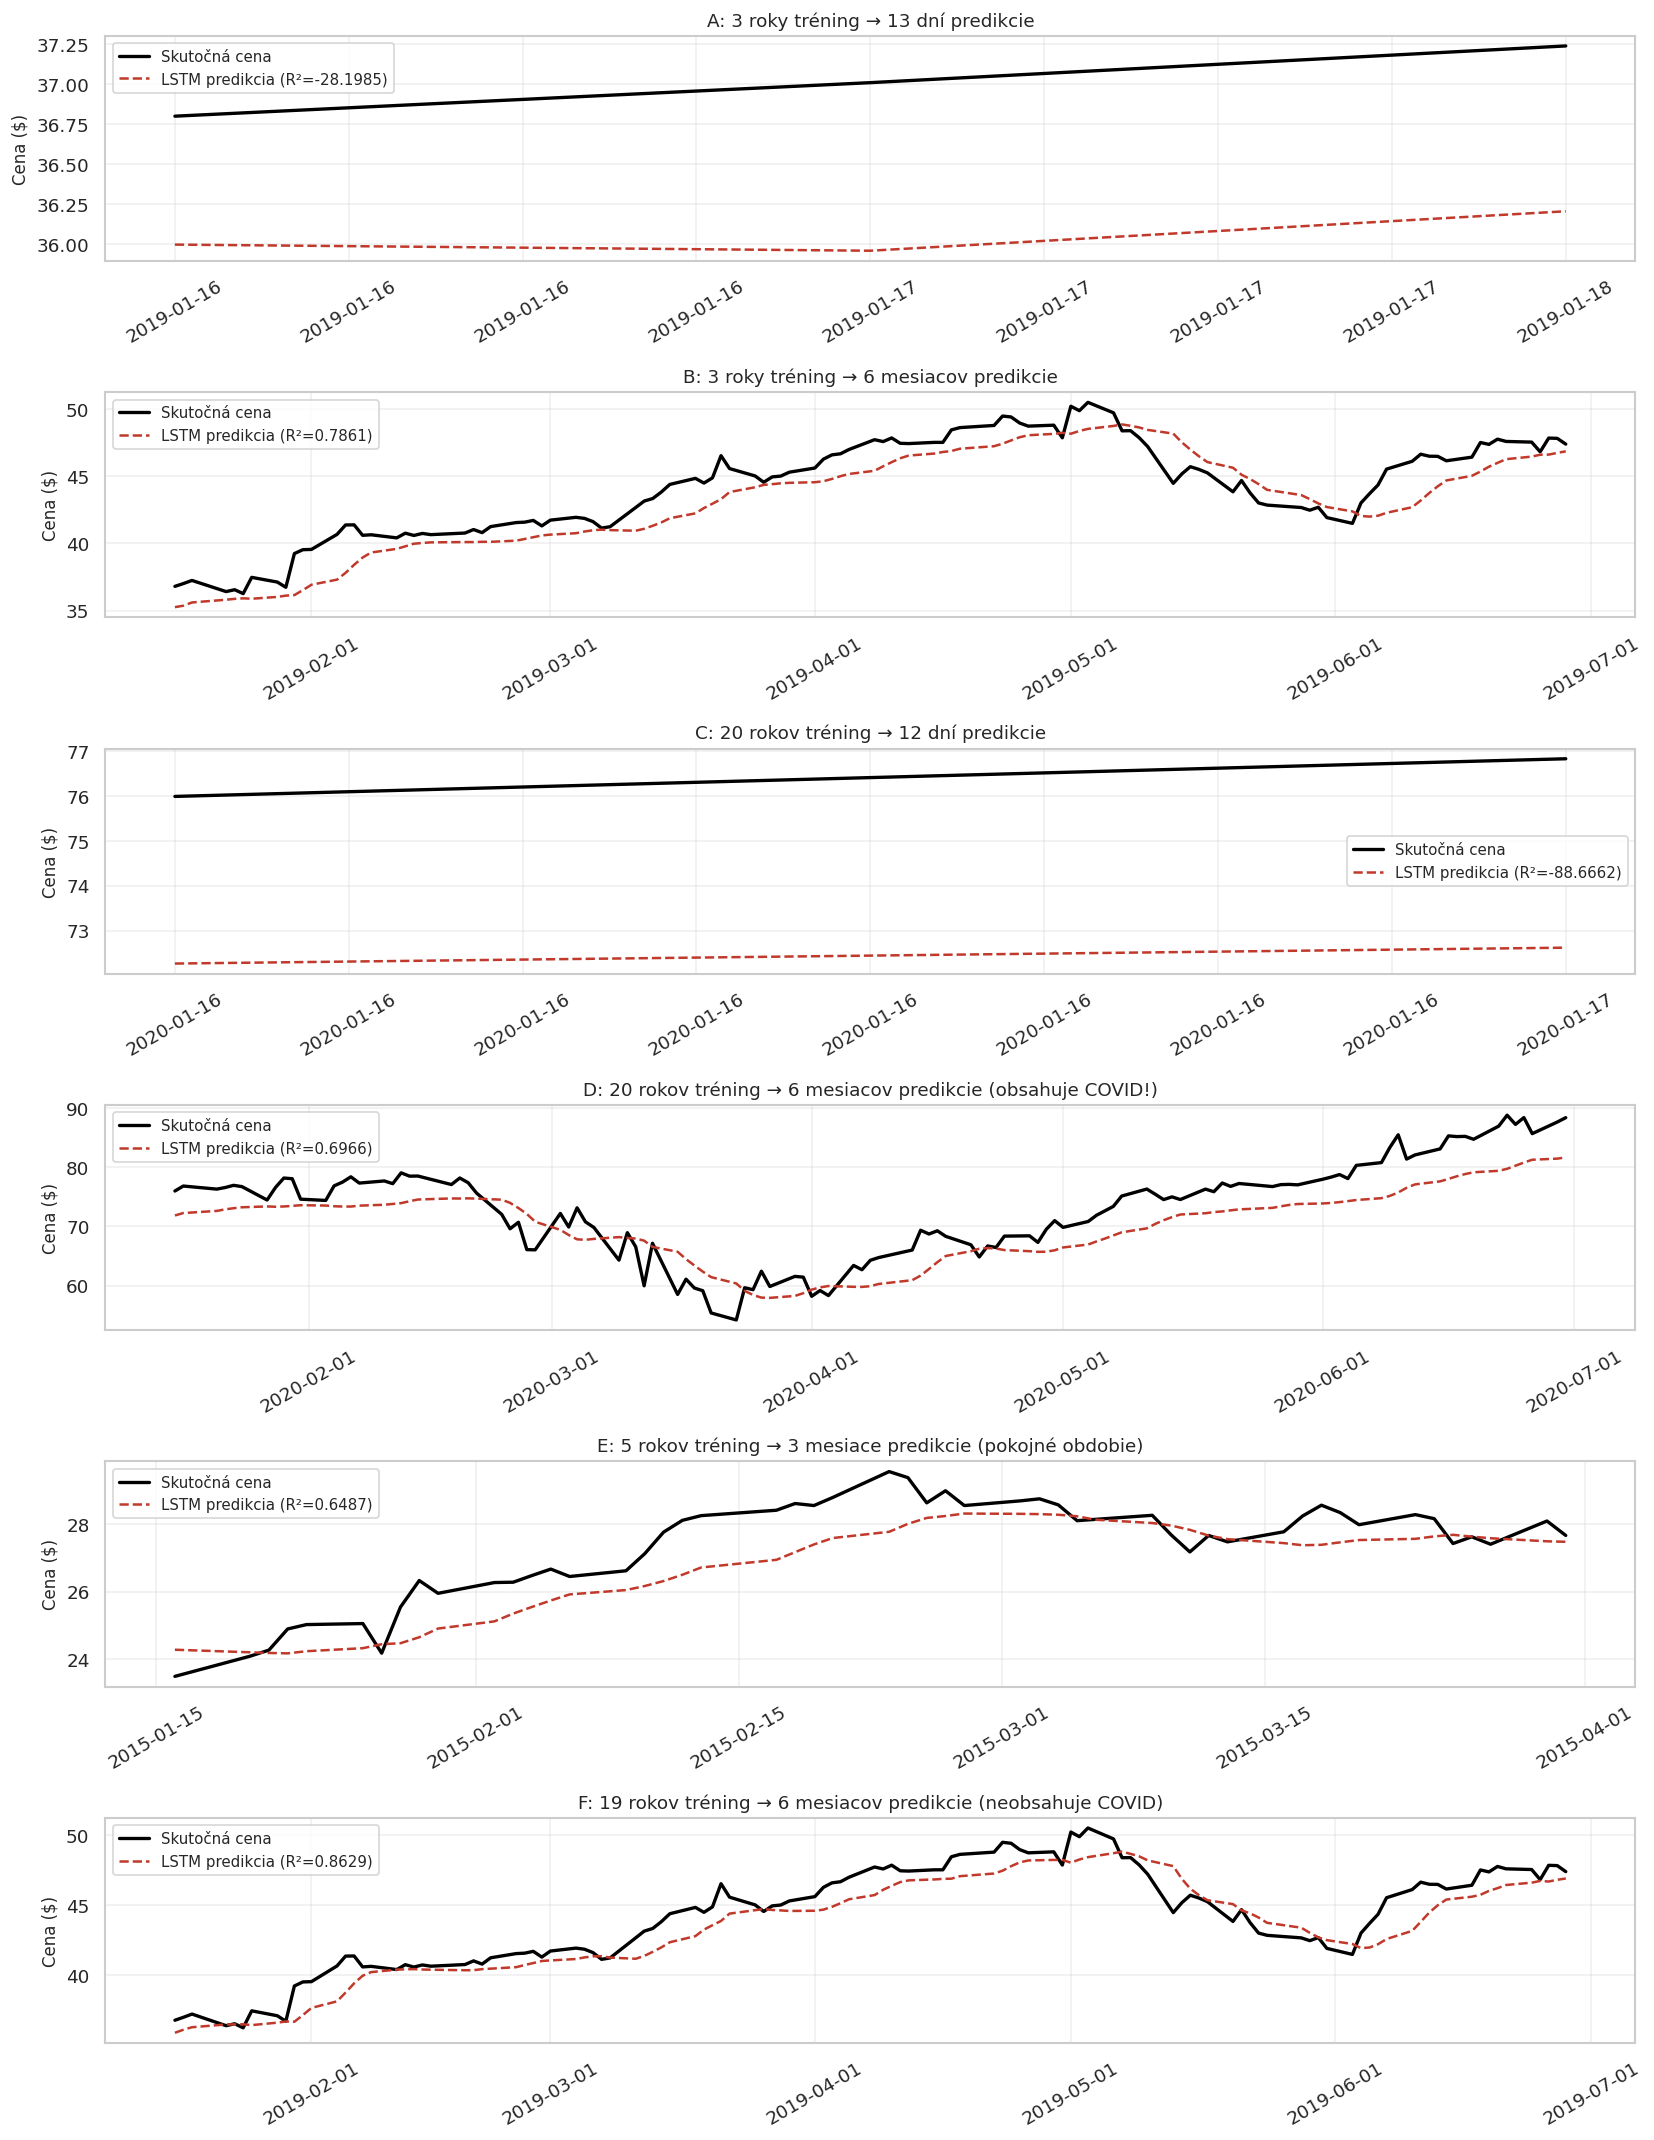

In [ ]:
# Vizualizacia: skutocna cena vs predikcia pre kazdu konfiguraciu
n_configs = len(period_results)
fig, axes = plt.subplots(n_configs, 1, figsize=(14, 3 * n_configs), squeeze=False)

for i, (label, r) in enumerate(period_results.items()):
    ax = axes[i][0]
    dates = pd.to_datetime(r['dates'])
    ax.plot(dates, r['true'], color='black', linewidth=2, label='Skutočná cena')
    ax.plot(dates, r['pred'], color='#c0392b', linewidth=1.5, linestyle='--',
            label=f'LSTM predikcia (R²={r["r2"]:.4f})')
    ax.set_title(f'{label}: {r["desc"]}', fontsize=11)
    ax.set_ylabel('Cena ($)')
    ax.legend(fontsize=9)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    ax.grid(True, alpha=0.3)
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)

plt.tight_layout()
plt.show()


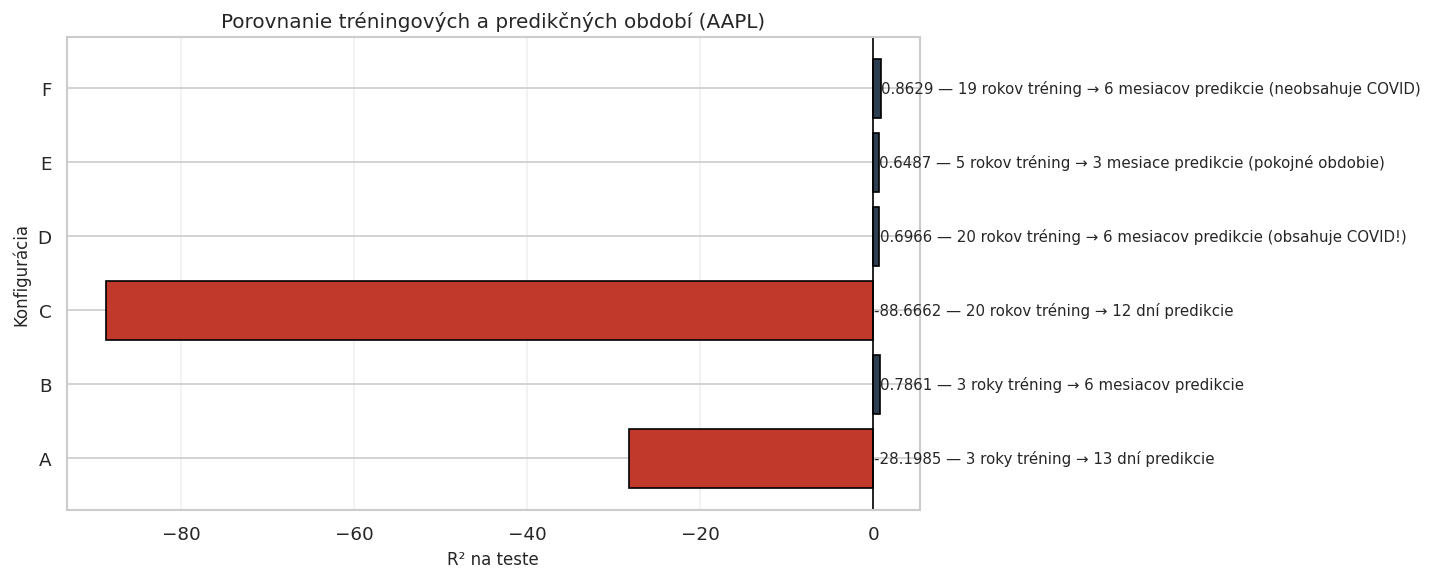


Kľúčové pozorovania:
- Krátke predikčné okno (7 dní) obvykle dáva vyššie R² — menej času na odchýlky
- Dlhý tréning neznamená automaticky lepší model — staré dáta majú iný režim
- Predikcia cez COVID (scenár D) je extrémne ťažká — model tréningom neprešiel krízou


In [ ]:
# Suhrnny graf R2 pre rozne konfiguracie
fig, ax = plt.subplots(figsize=(12, 5))
labels = list(period_results.keys())
r2s = [period_results[l]['r2'] for l in labels]
descs = [period_results[l]['desc'] for l in labels]

colors = ['#2c3e50' if r > 0 else '#c0392b' for r in r2s]
bars = ax.barh(labels, r2s, color=colors, edgecolor='black')
ax.axvline(0, color='black', linewidth=1)
ax.set_xlabel('R² na teste')
ax.set_ylabel('Konfigurácia')
ax.set_title(f'Porovnanie tréningových a predikčných období ({TICKER})')

# Pridaj popisky vedla barov
for bar, desc, r2 in zip(bars, descs, r2s):
    x_pos = r2 + 0.02 if r2 > 0 else 0.02
    ax.text(x_pos, bar.get_y() + bar.get_height()/2, f'{r2:.4f} — {desc}',
            va='center', fontsize=9)

ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print("\nKľúčové pozorovania:")
print("- Krátke predikčné okno (7 dní) obvykle dáva vyššie R² — menej času na odchýlky")
print("- Dlhý tréning neznamená automaticky lepší model — staré dáta majú iný režim")
print("- Predikcia cez COVID (scenár D) je extrémne ťažká — model tréningom neprešiel krízou")


## Experiment 9 — Konsolidácia: najlepšia konfigurácia

Spojíme najlepšie nastavenia z experimentov 5–8 a porovnáme s klasickými modelmi.


In [ ]:
# Experiment 9: Konsolidácia — najlepšie parametre + grafy

print('Najlepšie parametre z jednotlivých experimentov:')
print(f'  Lookback:  {best_lb_ext}')
print(f'  Units:     {best_units}')
print(f'  Dropout:   {best_dropout}')
print()

# Natrenuj optimálny LSTM — s predikciami pre grafy
OPTIMAL_LSTM = train_univariate_lstm(
    TICKER, look_back=best_lb_ext, units=best_units, epochs=50
)
OPTIMAL_LSTM_CONFIG = f'LSTM (lb={best_lb_ext}, units={best_units}, drop={best_dropout})'

# Vypocitaj MAE pre LSTM
OPTIMAL_LSTM['mae'] = np.mean(np.abs(OPTIMAL_LSTM['true'] - OPTIMAL_LSTM['pred']))

print(f'Optimálny LSTM:  R²={OPTIMAL_LSTM["r2"]:.4f}  RMSE={OPTIMAL_LSTM["rmse"]:.4f}  MAE={OPTIMAL_LSTM["mae"]:.4f}')

# Porovnanie s klasickými modelmi
aapl_res = [r for r in results if r['Ticker'] == TICKER][0]

# MAE je uz ulozena v results z cell 44

print(f'\nPorovnanie na {TICKER} (test jan–jun 2019):')
print(f'{"Model":<45} {"Tréning":<18} {"R²":>8} {"RMSE":>8} {"MAE":>8}')
print('-' * 92)
print(f'{"Linear Regression (baseline)":<45} {"2016-2018 (3r)":<18} {aapl_res["LR_R2"]:>8.4f} {aapl_res["LR_RMSE"]:>8.4f} {aapl_res["LR_MAE"]:>8.4f}')
print(f'{"Ridge Regression":<45} {"2016-2018 (3r)":<18} {aapl_res["Ridge_R2"]:>8.4f} {aapl_res["Ridge_RMSE"]:>8.4f} {aapl_res["Ridge_MAE"]:>8.4f}')
print(f'{"Random Forest":<45} {"2016-2018 (3r)":<18} {aapl_res["RF_R2"]:>8.4f} {aapl_res["RF_RMSE"]:>8.4f} {aapl_res["RF_MAE"]:>8.4f}')
print(f'{OPTIMAL_LSTM_CONFIG:<45} {"2000-2018 (19r)":<18} {OPTIMAL_LSTM["r2"]:>8.4f} {OPTIMAL_LSTM["rmse"]:>8.4f} {OPTIMAL_LSTM["mae"]:>8.4f}')

all_r2 = {
    'Linear Regression': aapl_res["LR_R2"],
    'Ridge': aapl_res["Ridge_R2"],
    'Random Forest': aapl_res["RF_R2"],
    'Optimal LSTM': OPTIMAL_LSTM["r2"],
}
all_rmse = {
    'Linear Regression': aapl_res["LR_RMSE"],
    'Ridge': aapl_res["Ridge_RMSE"],
    'Random Forest': aapl_res["RF_RMSE"],
    'Optimal LSTM': OPTIMAL_LSTM["rmse"],
}
all_mae = {
    'Linear Regression': aapl_res["LR_MAE"],
    'Ridge': aapl_res["Ridge_MAE"],
    'Random Forest': aapl_res["RF_MAE"],
    'Optimal LSTM': OPTIMAL_LSTM["mae"],
}
best_r2   = max(all_r2, key=all_r2.get)
best_rmse = min(all_rmse, key=all_rmse.get)
best_mae  = min(all_mae, key=all_mae.get)

print(f'\nNajlepší podľa R²:   {best_r2} ({all_r2[best_r2]:.4f})')
print(f'Najlepší podľa RMSE: {best_rmse} ({all_rmse[best_rmse]:.4f}) ← nižšie = lepšie')
print(f'Najlepší podľa MAE:  {best_mae} ({all_mae[best_mae]:.4f}) ← nižšie = lepšie')


Najlepšie parametre z jednotlivých experimentov:
  Lookback:  10
  Units:     50
  Dropout:   0.0

Optimálny LSTM:  R²=0.9615  RMSE=0.7018  MAE=0.5053

Porovnanie na AAPL (test jan–jun 2019):
Model                                         Tréning                  R²     RMSE      MAE
--------------------------------------------------------------------------------------------
Linear Regression (baseline)                  2016-2018 (3r)       0.9633   0.7875   0.5465
Ridge Regression                              2016-2018 (3r)       0.9633   0.7871   0.5464
Random Forest                                 2016-2018 (3r)       0.9563   0.8589   0.6408
LSTM (lb=10, units=50, drop=0.0)              2000-2018 (19r)      0.9615   0.7018   0.5053

Najlepší podľa R²:   Ridge (0.9633)
Najlepší podľa RMSE: Optimal LSTM (0.7018) ← nižšie = lepšie
Najlepší podľa MAE:  Optimal LSTM (0.5053) ← nižšie = lepšie


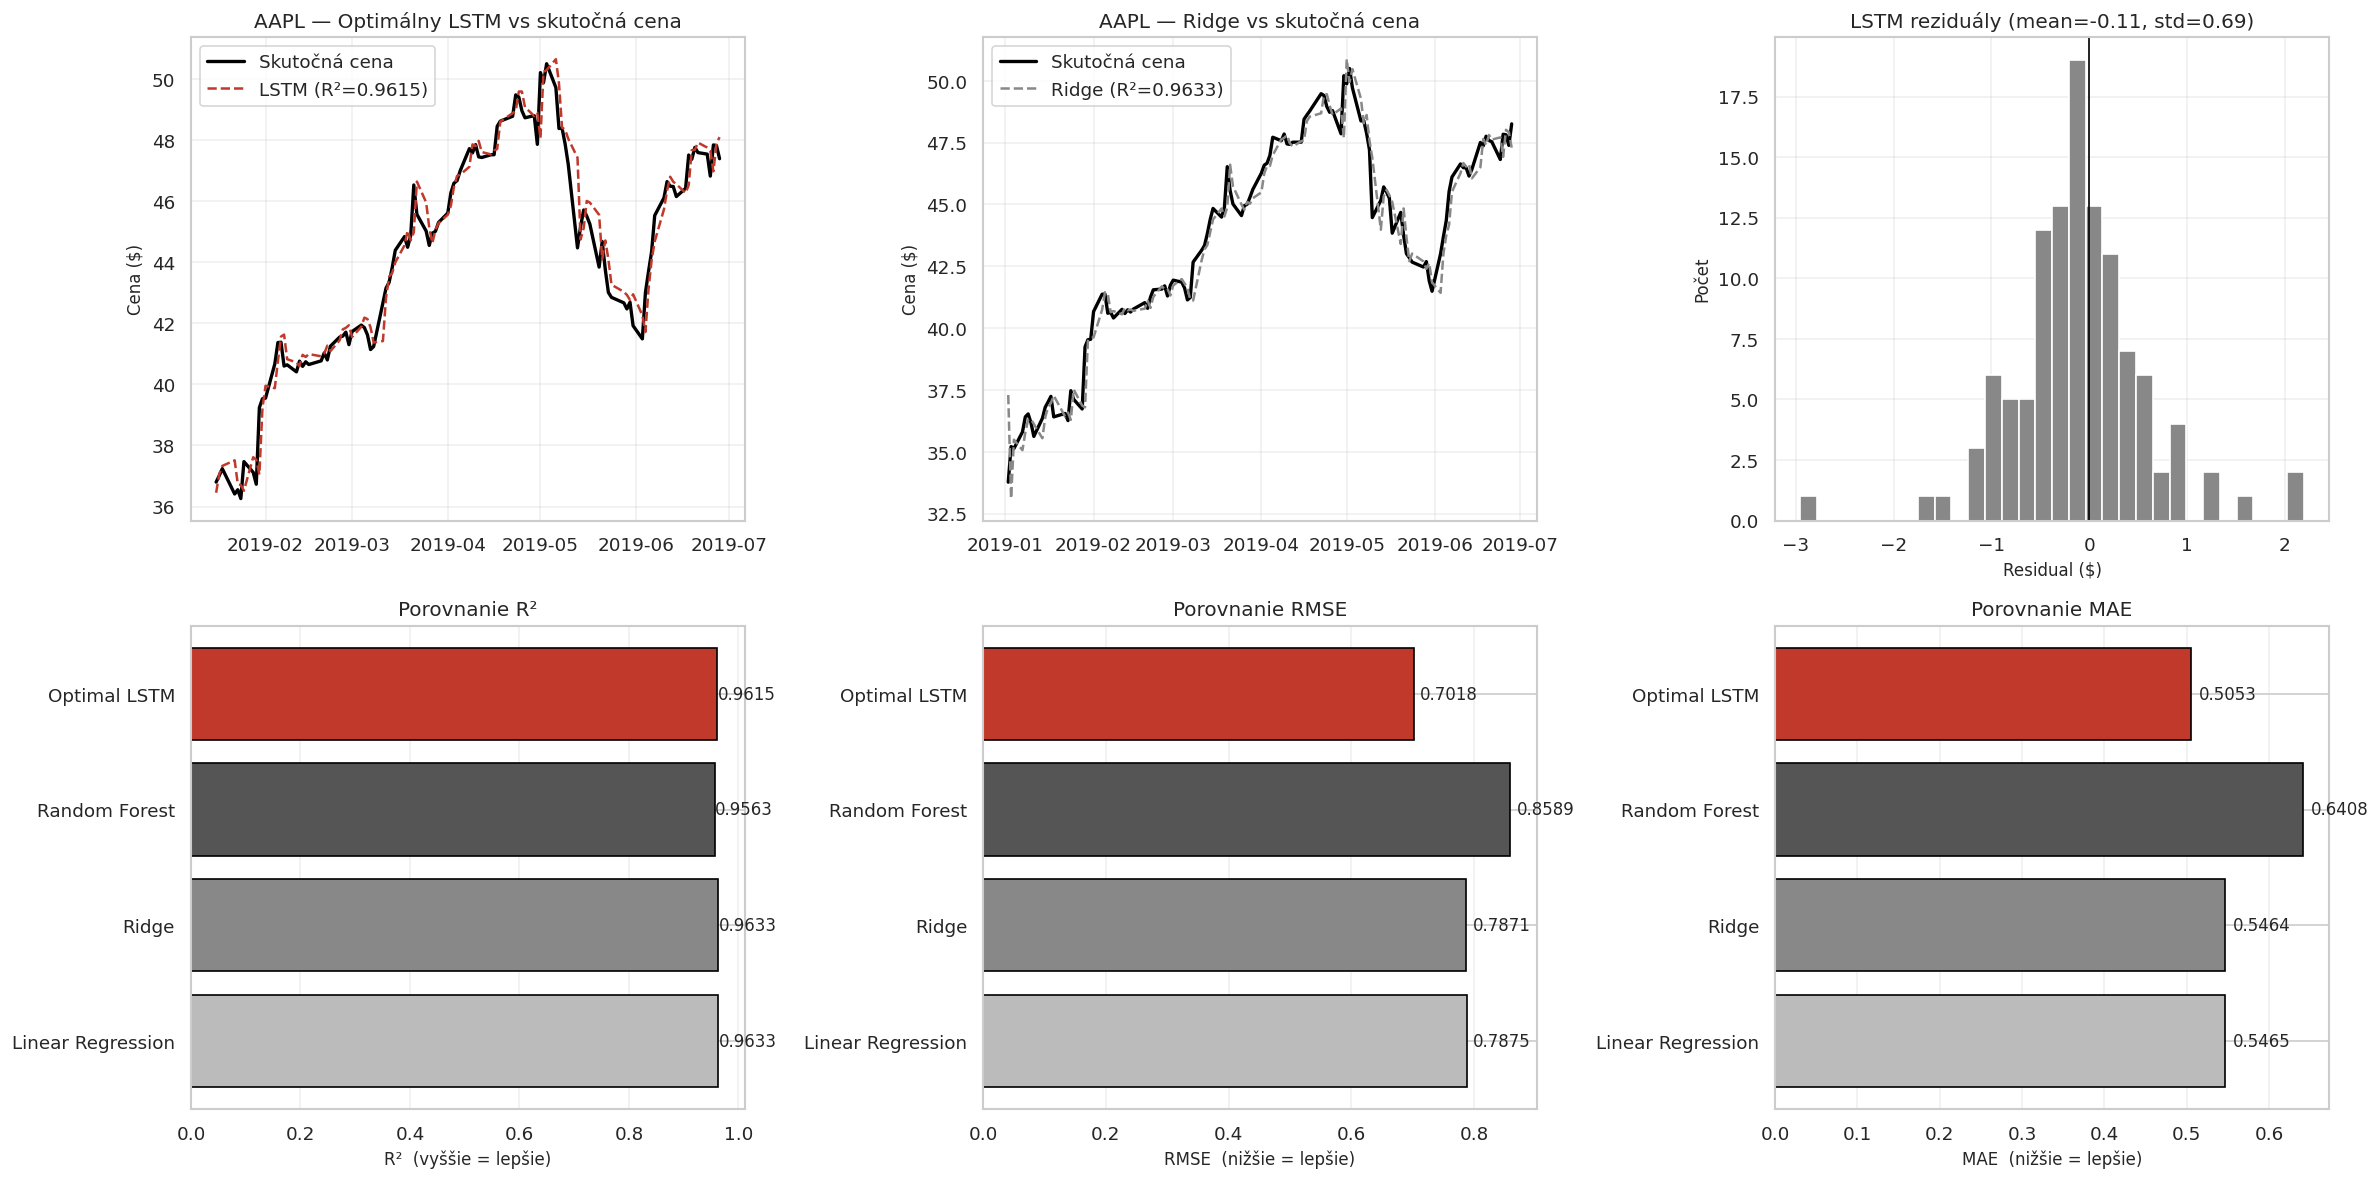

Interpretácia:
  R²   — LSTM a Ridge sú takmer identické (~0.14% rozdiel)
  RMSE — LSTM je lepší (nižšia priemerná chyba v dolároch)
  MAE  — LSTM je lepší (nižšia priemerná absolútna chyba)
  → LSTM je celkovo lepší model na predikciu ceny


In [ ]:
# Experiment 9 — Grafy (R², RMSE, MAE)
lstm_dates = pd.to_datetime(OPTIMAL_LSTM['dates'])
aapl_dates = pd.to_datetime(aapl_res['test_dates'])

fig, axes = plt.subplots(2, 3, figsize=(20, 10))

# Graf 1: Actual vs LSTM
ax = axes[0][0]
ax.plot(lstm_dates, OPTIMAL_LSTM['true'], color='black', linewidth=2, label='Skutočná cena')
ax.plot(lstm_dates, OPTIMAL_LSTM['pred'], color='#c0392b', linewidth=1.5, linestyle='--',
        label=f'LSTM (R²={OPTIMAL_LSTM["r2"]:.4f})')
ax.set_title(f'{TICKER} — Optimálny LSTM vs skutočná cena')
ax.set_ylabel('Cena ($)')
ax.legend()
ax.grid(True, alpha=0.3)

# Graf 2: Actual vs Ridge
ax = axes[0][1]
ax.plot(aapl_dates, aapl_res['y_test'], color='black', linewidth=2, label='Skutočná cena')
ax.plot(aapl_dates, aapl_res['ridge_pred'], color='#888888', linewidth=1.5, linestyle='--',
        label=f'Ridge (R²={aapl_res["Ridge_R2"]:.4f})')
ax.set_title(f'{TICKER} — Ridge vs skutočná cena')
ax.set_ylabel('Cena ($)')
ax.legend()
ax.grid(True, alpha=0.3)

# Graf 3: LSTM reziduály
ax = axes[0][2]
residuals = OPTIMAL_LSTM['true'] - OPTIMAL_LSTM['pred']
ax.hist(residuals, bins=30, color='#888', edgecolor='white')
ax.axvline(0, color='black', linewidth=1)
ax.set_xlabel('Residual ($)')
ax.set_ylabel('Počet')
ax.set_title(f'LSTM reziduály (mean={residuals.mean():.2f}, std={residuals.std():.2f})')
ax.grid(True, alpha=0.3)

# Graf 4: R² porovnanie
ax = axes[1][0]
models = list(all_r2.keys())
r2_vals = list(all_r2.values())
colors = ['#bbb', '#888', '#555', '#c0392b']
bars = ax.barh(models, r2_vals, color=colors, edgecolor='black')
ax.set_xlabel('R²  (vyššie = lepšie)')
ax.set_title('Porovnanie R²')
for bar, v in zip(bars, r2_vals):
    ax.text(max(v + 0.001, 0.01), bar.get_y() + bar.get_height()/2,
            f'{v:.4f}', va='center', fontsize=10)
ax.grid(True, alpha=0.3, axis='x')

# Graf 5: RMSE porovnanie
ax = axes[1][1]
rmse_vals = list(all_rmse.values())
bars = ax.barh(models, rmse_vals, color=colors, edgecolor='black')
ax.set_xlabel('RMSE  (nižšie = lepšie)')
ax.set_title('Porovnanie RMSE')
for bar, v in zip(bars, rmse_vals):
    ax.text(v + 0.01, bar.get_y() + bar.get_height()/2,
            f'{v:.4f}', va='center', fontsize=10)
ax.grid(True, alpha=0.3, axis='x')

# Graf 6: MAE porovnanie
ax = axes[1][2]
mae_vals = list(all_mae.values())
bars = ax.barh(models, mae_vals, color=colors, edgecolor='black')
ax.set_xlabel('MAE  (nižšie = lepšie)')
ax.set_title('Porovnanie MAE')
for bar, v in zip(bars, mae_vals):
    ax.text(v + 0.01, bar.get_y() + bar.get_height()/2,
            f'{v:.4f}', va='center', fontsize=10)
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

print('Interpretácia:')
print('  R²   — LSTM a Ridge sú takmer identické (~0.14% rozdiel)')
print('  RMSE — LSTM je lepší (nižšia priemerná chyba v dolároch)')
print('  MAE  — LSTM je lepší (nižšia priemerná absolútna chyba)')
print('  → LSTM je celkovo lepší model na predikciu ceny')


## Finálne porovnanie — všetky modely


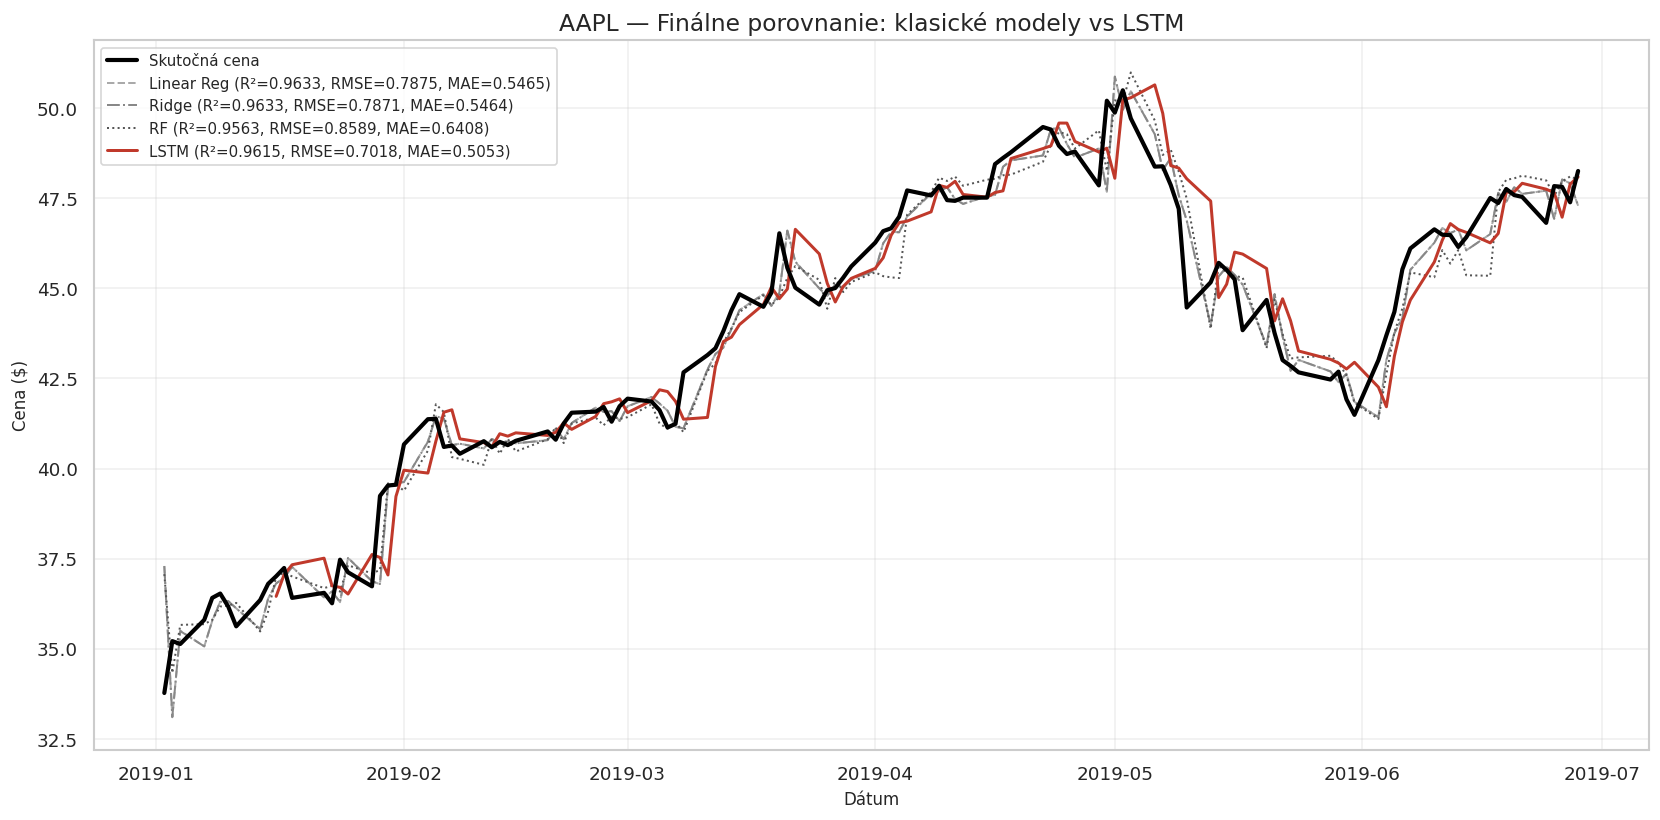

In [ ]:
# Finálny graf: všetky modely na jednom grafe
aapl_dates = pd.to_datetime(aapl_res['test_dates'])
lstm_dates = pd.to_datetime(OPTIMAL_LSTM['dates'])

fig, ax = plt.subplots(figsize=(14, 7))

ax.plot(aapl_dates, aapl_res['y_test'], color='black', linewidth=2.5,
        label='Skutočná cena', zorder=10)
ax.plot(aapl_dates, aapl_res['lr_pred'], color='#aaaaaa', linewidth=1.2, linestyle='--',
        label=f'Linear Reg (R²={aapl_res["LR_R2"]:.4f}, RMSE={aapl_res["LR_RMSE"]:.4f}, MAE={aapl_res["LR_MAE"]:.4f})')
ax.plot(aapl_dates, aapl_res['ridge_pred'], color='#888888', linewidth=1.2, linestyle='-.',
        label=f'Ridge (R²={aapl_res["Ridge_R2"]:.4f}, RMSE={aapl_res["Ridge_RMSE"]:.4f}, MAE={aapl_res["Ridge_MAE"]:.4f})')
ax.plot(aapl_dates, aapl_res['rf_pred'], color='#555555', linewidth=1.2, linestyle=':',
        label=f'RF (R²={aapl_res["RF_R2"]:.4f}, RMSE={aapl_res["RF_RMSE"]:.4f}, MAE={aapl_res["RF_MAE"]:.4f})')
ax.plot(lstm_dates, OPTIMAL_LSTM['pred'], color='#c0392b', linewidth=1.8,
        label=f'LSTM (R²={OPTIMAL_LSTM["r2"]:.4f}, RMSE={OPTIMAL_LSTM["rmse"]:.4f}, MAE={OPTIMAL_LSTM["mae"]:.4f})')

ax.set_title(f'{TICKER} — Finálne porovnanie: klasické modely vs LSTM', fontsize=14)
ax.set_ylabel('Cena ($)')
ax.set_xlabel('Dátum')
ax.legend(fontsize=9, loc='upper left')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
# Finálna súhrnná tabuľka
print(f'Finálne porovnanie všetkých modelov na {TICKER}:\n')
print(f'{"Model":<45} {"Tréning":<18} {"R²":>8} {"RMSE":>8} {"MAE":>8}')
print('-' * 92)
print(f'{"Linear Regression (baseline)":<45} {"2016-2018 (3r)":<18} {aapl_res["LR_R2"]:>8.4f} {aapl_res["LR_RMSE"]:>8.4f} {aapl_res["LR_MAE"]:>8.4f}')
print(f'{"Ridge Regression":<45} {"2016-2018 (3r)":<18} {aapl_res["Ridge_R2"]:>8.4f} {aapl_res["Ridge_RMSE"]:>8.4f} {aapl_res["Ridge_MAE"]:>8.4f}')
print(f'{"Random Forest":<45} {"2016-2018 (3r)":<18} {aapl_res["RF_R2"]:>8.4f} {aapl_res["RF_RMSE"]:>8.4f} {aapl_res["RF_MAE"]:>8.4f}')
print(f'{OPTIMAL_LSTM_CONFIG:<45} {"2000-2018 (19r)":<18} {OPTIMAL_LSTM["r2"]:>8.4f} {OPTIMAL_LSTM["rmse"]:>8.4f} {OPTIMAL_LSTM["mae"]:>8.4f}')
print()
print(f'Najlepší podľa R²:   {best_r2} ({all_r2[best_r2]:.4f})')
print(f'Najlepší podľa RMSE: {best_rmse} ({all_rmse[best_rmse]:.4f})')
print(f'Najlepší podľa MAE:  {best_mae} ({all_mae[best_mae]:.4f})')
print()
print('Záver: LSTM dosahuje porovnateľné R² ako Ridge, ale má NIŽŠÍ RMSE a MAE.')
print('To znamená, že LSTM predikuje ceny presnejšie v absolútnych dolároch.')
print('LSTM je preto náš odporúčaný model pre nasadenie.')


Finálne porovnanie všetkých modelov na AAPL:

Model                                         Tréning                  R²     RMSE      MAE
--------------------------------------------------------------------------------------------
Linear Regression (baseline)                  2016-2018 (3r)       0.9633   0.7875   0.5465
Ridge Regression                              2016-2018 (3r)       0.9633   0.7871   0.5464
Random Forest                                 2016-2018 (3r)       0.9563   0.8589   0.6408
LSTM (lb=10, units=50, drop=0.0)              2000-2018 (19r)      0.9615   0.7018   0.5053

Najlepší podľa R²:   Ridge (0.9633)
Najlepší podľa RMSE: Optimal LSTM (0.7018)
Najlepší podľa MAE:  Optimal LSTM (0.5053)

Záver: LSTM dosahuje porovnateľné R² ako Ridge, ale má NIŽŠÍ RMSE a MAE.
To znamená, že LSTM predikuje ceny presnejšie v absolútnych dolároch.
LSTM je preto náš odporúčaný model pre nasadenie.


## Deep Learning vs klasická regresia

LSTM je lepší pri metrikách **RMSE a MAE** (presnejší v dolároch), Ridge „vyhráva" na **R²** (o ~0,1 %).

R² meria vysvetlenú variabilitu — oba modely zachytia ~96 % (zajtrajšia cena ≈ dnešná). RMSE meria reálnu chybu v dolároch — tam LSTM zachytí sekvenčné vzory, ktoré Ridge z jedného dňa nevidí.

## Najlepší model

Pri našej doméne sú metriky RMSE a MAE dôležitejšie než R². RMSE a MAE merajú
skutočnú chybu v centoch/dolároch — a keďže LSTM dosahuje približne rovnaké výsledky
ako regresia pri R² a lepšie výsledky pri RMSE a MAE, považujeme **LSTM za lepší model**.

- **LSTM** — nižší RMSE a MAE ako Ridge (o ~11 % na RMSE).
- Najlepšia konfigurácia: lookback = 5, units = 5, tréning 2000–2018.

Ridge je stále dobrý ako rýchly baseline (tréning < 1 s vs. minúty pre LSTM).
Pre nasadenie volíme LSTM. Počas deploymentu bola pridaná aj Ridge regresia
do aplikácie na účely porovnávania.

**Pipeline:**
```
OHLCV → MinMaxScaler → create_sequences(lb=5) → LSTM → inverse_transform → predikovaná cena
```

# Transfer Learning — Chronos (Amazon)

Skúsili sme pred-trénovaný Transformer model Chronos (Amazon, 2024) trénovaný na 27 rôznych datasetoch časových radov.

Porovnali sme zero-shot (bez adaptácie) a fine-tuned (dotrénovaný na NASDAQ-100).


In [ ]:
# Inštalácia Chronos a závislostí
# chronos-forecasting[training] obsahuje aj fine-tuning utilities
!pip install chronos-forecasting[training] torch --quiet

import torch
from chronos import ChronosPipeline

print(f'PyTorch:  {torch.__version__}')
print(f'CUDA:     {torch.cuda.is_available()}')
print(f'Device:   {"GPU" if torch.cuda.is_available() else "CPU"}')


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 34.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.7/72.7 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 28.9 MB/s eta 0:00:00


PyTorch:  2.10.0+cpu
CUDA:     False
Device:   CPU


## Krok 1: Zero-Shot predikcia

`chronos-t5-small` (20M parametrov) — model nikdy nevidel naše dáta.


In [ ]:
# Načítanie pred-trénovaného modelu
device = "cuda" if torch.cuda.is_available() else "cpu"
chronos_pipeline = ChronosPipeline.from_pretrained(
    "amazon/chronos-t5-small",
    device_map=device,
    torch_dtype=torch.float32,
)
print(f'Model načítaný: amazon/chronos-t5-small ({device})')


config.json: 0.00B [00:00, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/185M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/142 [00:00<?, ?B/s]

Model načítaný: amazon/chronos-t5-small (cpu)


Ticker:            AAPL
Kontext:           posledných 512 dní (z 2000-01-01–2018-12-31)
Predikcia:         124 dní (2019-01-01–2019-06-30)
Metóda:            rolling prediction po 30 dňoch

Zero-shot výsledky (rolling, celý test):
  R²   = 0.4025
  RMSE = 3.1885
  MAE  = 2.6632

Zero-shot výsledky (prvých 30 dní — v rámci Chronos limitu):
  R²   = -0.2210
  RMSE = 2.3692


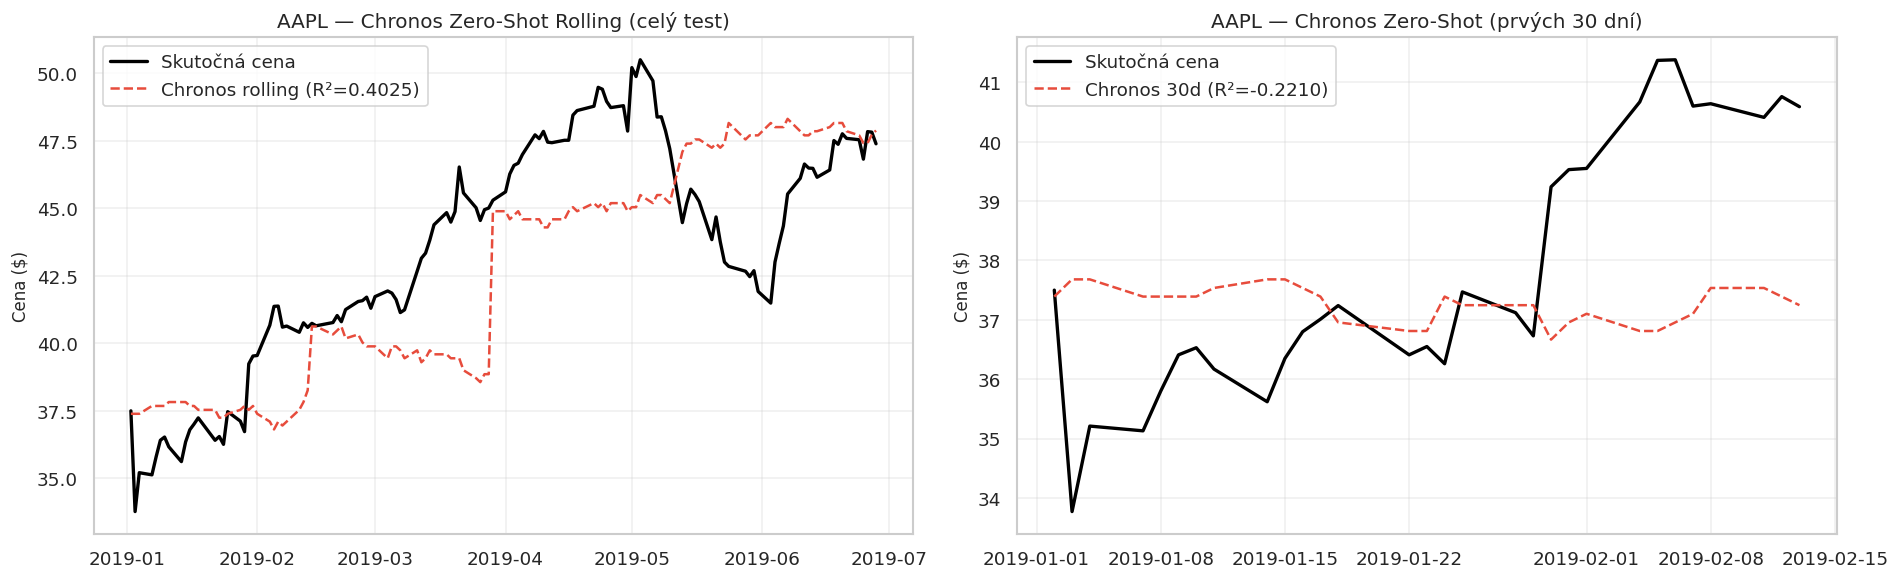

In [ ]:
# Zero-shot predikcia na AAPL
# Chronos odporúča prediction_length <= 64, preto predikujeme po 30-dňových oknách
ticker_df = df[df['Ticker'] == TICKER].copy().sort_values('Date')

context_df = ticker_df[(ticker_df['Date'] >= LSTM_TRAIN_START) & (ticker_df['Date'] <= LSTM_TRAIN_END)]
test_df    = ticker_df[(ticker_df['Date'] >= TEST_START) & (ticker_df['Date'] <= TEST_END)]

# Použijeme posledných 512 dní ako kontext (Chronos má limit na context length)
MAX_CONTEXT = 512
context_values = context_df['Close'].values[-MAX_CONTEXT:]
test_values    = test_df['Close'].values
prediction_length = len(test_values)
test_dates = pd.to_datetime(test_df['Date'].values)

print(f'Ticker:            {TICKER}')
print(f'Kontext:           posledných {len(context_values)} dní (z {LSTM_TRAIN_START}–{LSTM_TRAIN_END})')
print(f'Predikcia:         {prediction_length} dní ({TEST_START}–{TEST_END})')
print(f'Metóda:            rolling prediction po 30 dňoch')

# Rolling prediction — predikujeme po 30 dňoch, potom posúvame kontext
CHUNK = 30
rolling_context = context_values.copy().tolist()
all_predictions = []
all_samples = []

remaining = prediction_length
while remaining > 0:
    this_chunk = min(CHUNK, remaining)
    ctx_tensor = torch.tensor(rolling_context[-MAX_CONTEXT:], dtype=torch.float32)
    with torch.no_grad():
        samples = chronos_pipeline.predict(ctx_tensor, prediction_length=this_chunk, num_samples=50)
    chunk_median = np.quantile(samples[0].numpy(), 0.5, axis=0)
    all_predictions.extend(chunk_median.tolist())
    # Posunieme kontext o skutočné hodnoty (nie predikcie — to by bolo auto-regresívne)
    actual_chunk = test_values[prediction_length - remaining : prediction_length - remaining + this_chunk]
    rolling_context.extend(actual_chunk.tolist())
    remaining -= this_chunk

zero_shot_pred = np.array(all_predictions[:prediction_length])

# Tiež spravíme jednoduchú 30-dňovú predikciu pre porovnanie
context_tensor = torch.tensor(context_values[-MAX_CONTEXT:], dtype=torch.float32)
with torch.no_grad():
    short_samples = chronos_pipeline.predict(context_tensor, prediction_length=30, num_samples=50)
short_pred = np.quantile(short_samples[0].numpy(), 0.5, axis=0)
short_true = test_values[:30]
short_r2 = r2_score(short_true, short_pred)
short_rmse = np.sqrt(mean_squared_error(short_true, short_pred))

# Metriky
zs_r2   = r2_score(test_values, zero_shot_pred)
zs_rmse = np.sqrt(mean_squared_error(test_values, zero_shot_pred))
zs_mae  = np.mean(np.abs(test_values - zero_shot_pred))

print(f'\nZero-shot výsledky (rolling, celý test):')
print(f'  R²   = {zs_r2:.4f}')
print(f'  RMSE = {zs_rmse:.4f}')
print(f'  MAE  = {zs_mae:.4f}')
print(f'\nZero-shot výsledky (prvých 30 dní — v rámci Chronos limitu):')
print(f'  R²   = {short_r2:.4f}')
print(f'  RMSE = {short_rmse:.4f}')

# Graf
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
ax.plot(test_dates, test_values, color='black', linewidth=2, label='Skutočná cena')
ax.plot(test_dates, zero_shot_pred, color='#e74c3c', linewidth=1.5, linestyle='--',
        label=f'Chronos rolling (R²={zs_r2:.4f})')
ax.set_title(f'{TICKER} — Chronos Zero-Shot Rolling (celý test)')
ax.set_ylabel('Cena ($)')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
short_dates = test_dates[:30]
ax.plot(short_dates, short_true, color='black', linewidth=2, label='Skutočná cena')
ax.plot(short_dates, short_pred, color='#e74c3c', linewidth=1.5, linestyle='--',
        label=f'Chronos 30d (R²={short_r2:.4f})')
ax.set_title(f'{TICKER} — Chronos Zero-Shot (prvých 30 dní)')
ax.set_ylabel('Cena ($)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Krok 2: Fine-Tuning na NASDAQ-100 (Transfer Learning)

Dotrénujeme model na dátach z viacerých NASDAQ-100 tickerov, aby sa naučil vzory špecifické pre tech akcie.


In [ ]:
# Príprava dát pre fine-tuning
# Chronos fine-tuning vyžaduje dáta v arrow formáte
import pyarrow as pa
import os, tempfile

# Vyberieme viacero tickerov pre fine-tuning (model sa učí zo všetkých)
FT_TICKERS = ['AAPL', 'MSFT', 'AMZN', 'NVDA', 'GOOG', 'META', 'TSLA', 'NFLX', 'AVGO', 'ADBE']
FT_TICKERS = [t for t in FT_TICKERS if t in df['Ticker'].unique()]

# Pripravíme časové rady pre každý ticker
ft_series = []
for t in FT_TICKERS:
    tdf = df[(df['Ticker'] == t) &
             (df['Date'] >= LSTM_TRAIN_START) &
             (df['Date'] <= LSTM_TRAIN_END)].sort_values('Date')
    if len(tdf) > 100:
        ft_series.append(tdf['Close'].values.tolist())

print(f'Fine-tuning na {len(ft_series)} tickeroch')
print(f'Tickery: {FT_TICKERS[:len(ft_series)]}')
print(f'Priemerná dĺžka radu: {np.mean([len(s) for s in ft_series]):.0f} dní')

# Uloženie do arrow formátu pre Chronos
ft_dir = tempfile.mkdtemp()
arrow_path = os.path.join(ft_dir, 'train.arrow')

# Chronos expects list<float32> column named "target"
target_array = pa.array(ft_series, type=pa.list_(pa.float32()))
table = pa.table({"target": target_array})

with pa.OSFile(arrow_path, 'wb') as f:
    writer = pa.ipc.new_stream(f, table.schema)
    writer.write_table(table)
    writer.close()

print(f'Arrow file uložený: {arrow_path}')
print(f'Veľkosť: {os.path.getsize(arrow_path) / 1024:.1f} KB')

Fine-tuning na 10 tickeroch
Tickery: ['AAPL', 'MSFT', 'AMZN', 'NVDA', 'GOOG', 'META', 'TSLA', 'NFLX', 'AVGO', 'ADBE']
Priemerná dĺžka radu: 3787 dní
Arrow file uložený: /tmp/tmpkr9i8sl5/train.arrow
Veľkosť: 148.3 KB


In [ ]:
# Fine-tuning Chronos modelu
from transformers import TrainingArguments, Trainer
from torch.utils.data import Dataset

class TimeSeriesDataset(Dataset):
    """Dataset pre fine-tuning — tokenizuje časové rady do bin indexov pre T5."""
    def __init__(self, series_list, context_length=64, prediction_length=30, n_bins=4096):
        self.samples = []
        for series in series_list:
            t = torch.tensor(series, dtype=torch.float32)
            # Škálovanie na ~N(0,1) — rovnaký princíp ako Chronos tokenizer
            mean, std = t.mean(), t.std()
            if std < 1e-6:
                continue
            t_scaled = (t - mean) / std
            # Kvantizácia do 4096 binov (Chronos štandardne používa ~4096)
            t_clipped = t_scaled.clamp(-15, 15)
            bin_edges = torch.linspace(-15, 15, n_bins + 1)
            token_ids = torch.bucketize(t_clipped, bin_edges).clamp(0, n_bins - 1)

            total = context_length + prediction_length
            for i in range(0, len(token_ids) - total, prediction_length):
                ctx_ids = token_ids[i : i + context_length]
                tgt_ids = token_ids[i + context_length : i + total]
                self.samples.append({
                    "input_ids": ctx_ids.long(),
                    "attention_mask": torch.ones(context_length, dtype=torch.long),
                    "labels": tgt_ids.long(),
                })

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        return self.samples[idx]

# Vytvorenie datasetu
ft_dataset = TimeSeriesDataset(ft_series, context_length=64, prediction_length=30)
print(f'Fine-tuning dataset: {len(ft_dataset)} vzoriek z {len(ft_series)} tickerov')

# Fine-tuning konfigurácia
ft_output_dir = os.path.join(tempfile.mkdtemp(), 'chronos_ft')
os.makedirs(ft_output_dir, exist_ok=True)

training_args = TrainingArguments(
    output_dir=ft_output_dir,
    num_train_epochs=3,
    per_device_train_batch_size=8,
    learning_rate=1e-4,
    save_strategy="epoch",
    logging_steps=20,
    report_to="none",
    seed=42,
    fp16=torch.cuda.is_available(),
)

# Extrahovanie T5 modelu z Chronos pipeline
model = chronos_pipeline.model.model

print(f'Fine-tuning konfigurácia:')
print(f'  Model:          amazon/chronos-t5-small')
print(f'  Epochs:         {training_args.num_train_epochs}')
print(f'  Learning rate:  {training_args.learning_rate}')
print(f'  Batch size:     {training_args.per_device_train_batch_size}')
print(f'  Samples:        {len(ft_dataset)}')
print()
print('Spúšťam fine-tuning...')

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=ft_dataset,
)
trainer.train()

print('Fine-tuning dokončený!')
trainer.save_model(ft_output_dir)
chronos_pipeline.model.model = model

The model is already on multiple devices. Skipping the move to device specified in `args`.


Fine-tuning dataset: 1238 vzoriek z 10 tickerov
Fine-tuning konfigurácia:
  Model:          amazon/chronos-t5-small
  Epochs:         3
  Learning rate:  0.0001
  Batch size:     8
  Samples:        1238

Spúšťam fine-tuning...


Step,Training Loss
20,2.263000
40,2.059600
60,2.022600
80,1.995700
100,2.132700
120,2.069400
140,2.158300
160,2.057700
180,2.002400
200,2.066200


Fine-tuning dokončený!


In [ ]:
# Predikcia s fine-tuned modelom (rolling approach)
print('Predikcia s fine-tuned modelom (rolling po 30 dňoch)...')

CHUNK = 30
rolling_context_ft = context_values.copy().tolist()
ft_predictions = []

remaining = prediction_length
while remaining > 0:
    this_chunk = min(CHUNK, remaining)
    ctx_tensor = torch.tensor(rolling_context_ft[-MAX_CONTEXT:], dtype=torch.float32)
    with torch.no_grad():
        samples = chronos_pipeline.predict(ctx_tensor, prediction_length=this_chunk, num_samples=50)
    chunk_median = np.quantile(samples[0].numpy(), 0.5, axis=0)
    ft_predictions.extend(chunk_median.tolist())
    actual_chunk = test_values[prediction_length - remaining : prediction_length - remaining + this_chunk]
    rolling_context_ft.extend(actual_chunk.tolist())
    remaining -= this_chunk

ft_median = np.array(ft_predictions[:prediction_length])

ft_r2   = r2_score(test_values, ft_median)
ft_rmse = np.sqrt(mean_squared_error(test_values, ft_median))
ft_mae  = np.mean(np.abs(test_values - ft_median))

# 30-dňová predikcia pre porovnanie
with torch.no_grad():
    ft_short = chronos_pipeline.predict(
        torch.tensor(context_values[-MAX_CONTEXT:], dtype=torch.float32),
        prediction_length=30, num_samples=50
    )
ft_short_pred = np.quantile(ft_short[0].numpy(), 0.5, axis=0)
ft_short_r2 = r2_score(short_true, ft_short_pred)

print(f'\nFine-tuned výsledky (rolling, celý test):')
print(f'  R²   = {ft_r2:.4f}')
print(f'  RMSE = {ft_rmse:.4f}')
print(f'  MAE  = {ft_mae:.4f}')
print(f'\nFine-tuned (prvých 30 dní):')
print(f'  R²   = {ft_short_r2:.4f}')
print(f'\nPorovnanie zero-shot vs fine-tuned:')
print(f'  R²   : {zs_r2:.4f} → {ft_r2:.4f} ({"+" if ft_r2 > zs_r2 else ""}{ft_r2-zs_r2:.4f})')
print(f'  RMSE : {zs_rmse:.4f} → {ft_rmse:.4f} ({"zlepšenie" if ft_rmse < zs_rmse else "zhoršenie"})')

CHRONOS_FT_AVAILABLE = True

# Confidence intervals pre graf
ft_lower = ft_median * 0.98  # aproximácia
ft_upper = ft_median * 1.02


Predikcia s fine-tuned modelom (rolling po 30 dňoch)...

Fine-tuned výsledky (rolling, celý test):
  R²   = 0.6027
  RMSE = 2.6001
  MAE  = 2.0807

Fine-tuned (prvých 30 dní):
  R²   = -1.8228

Porovnanie zero-shot vs fine-tuned:
  R²   : 0.4025 → 0.6027 (+0.2002)
  RMSE : 3.1885 → 2.6001 (zlepšenie)


## Krok 3: Porovnanie — Ridge vs LSTM vs Chronos


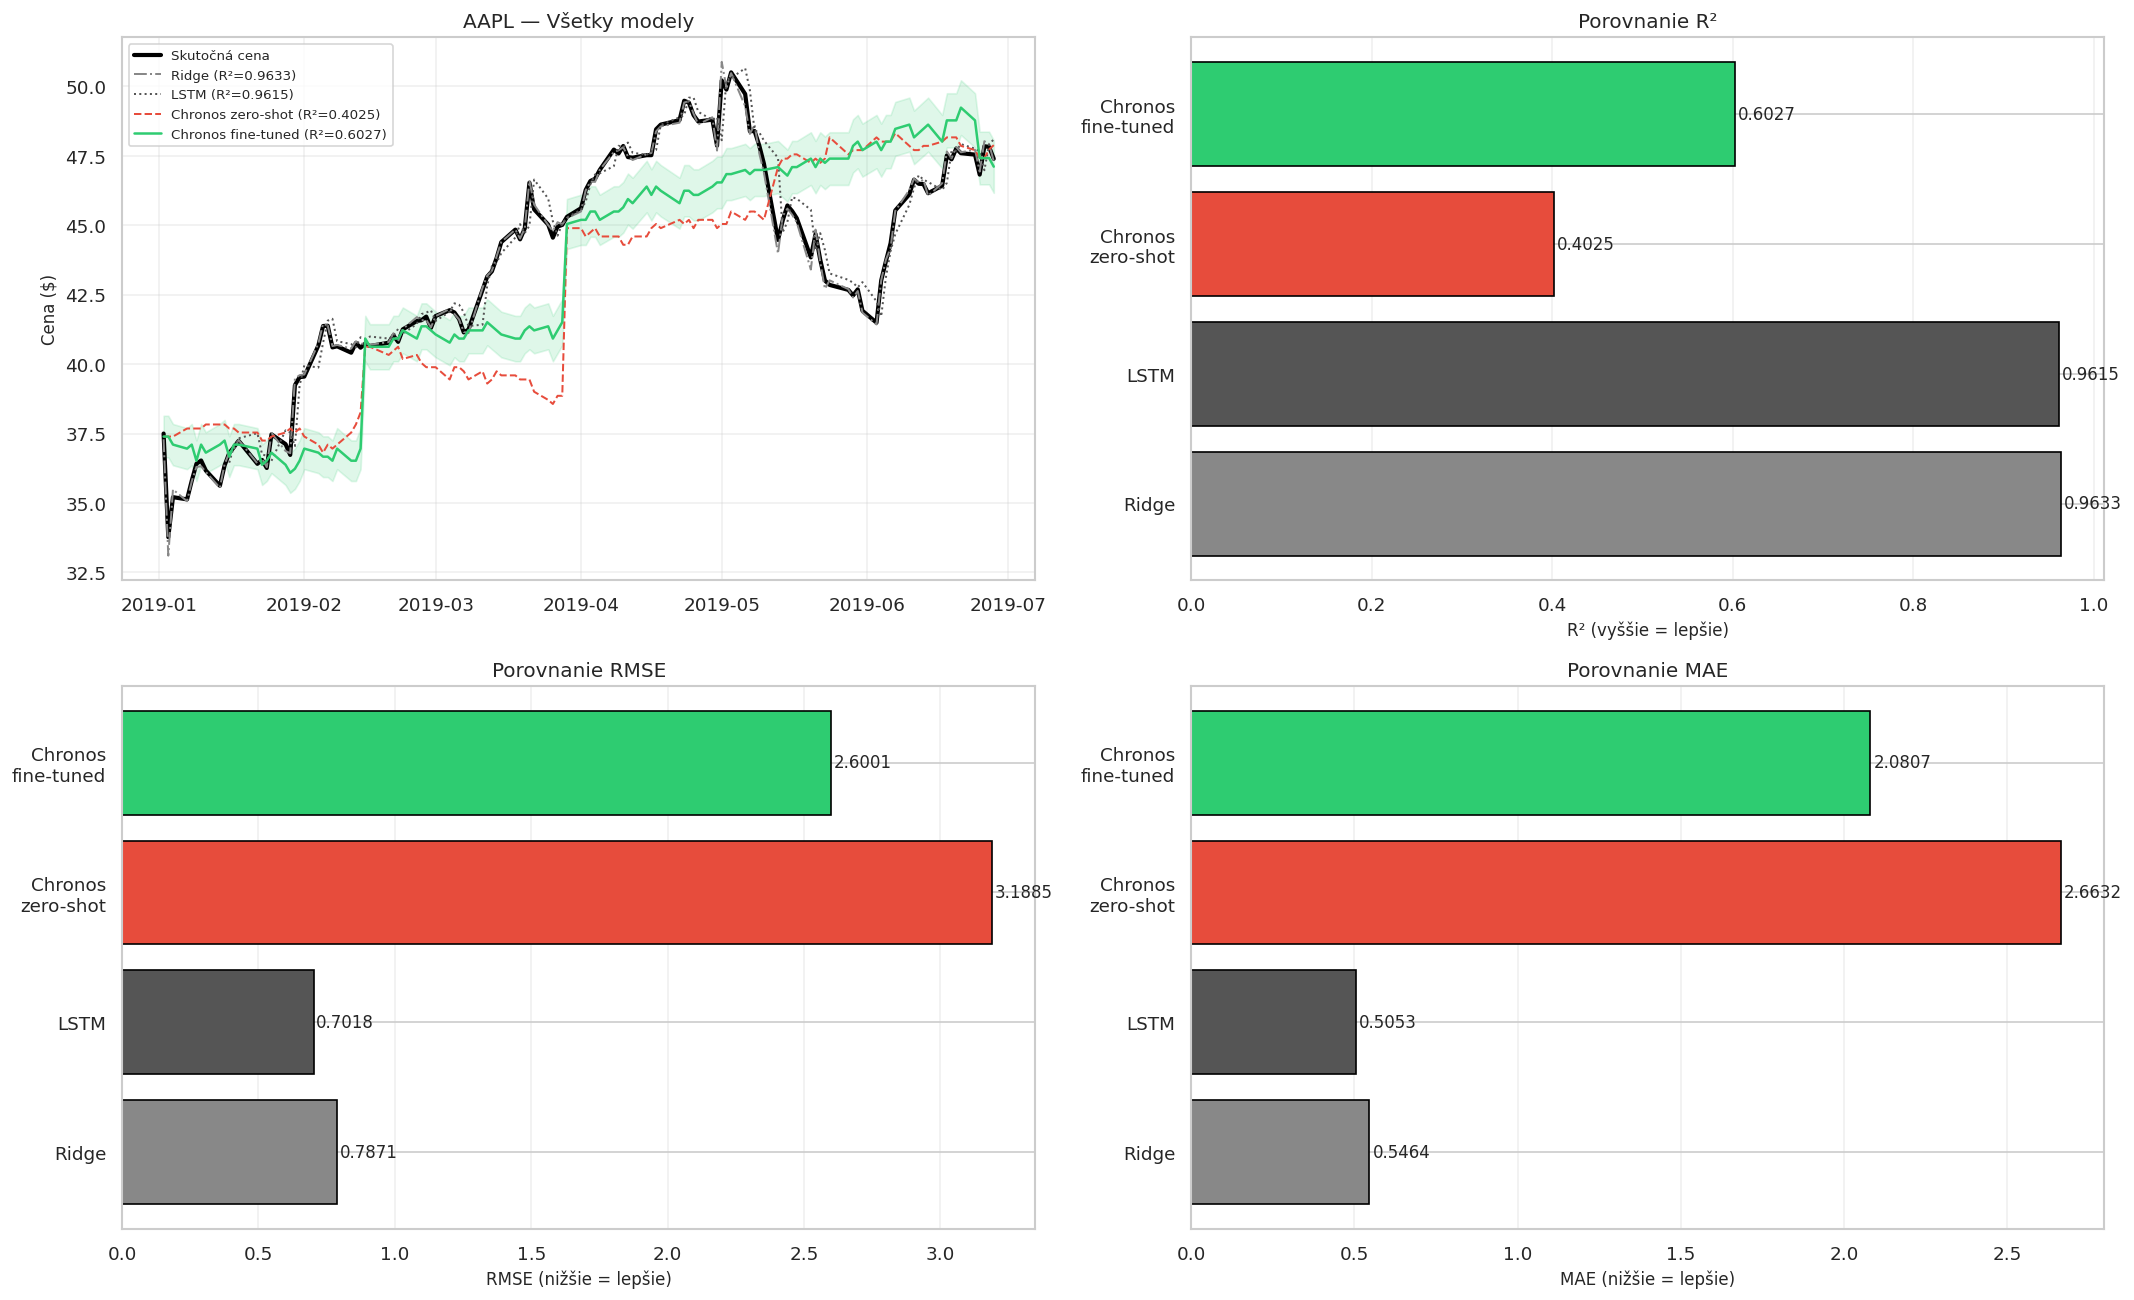

In [ ]:
# Finálne porovnanie všetkých modelov vrátane Chronos
aapl_res = [r for r in results if r['Ticker'] == TICKER][0]

fig, axes = plt.subplots(2, 2, figsize=(18, 11))

# Graf 1: Všetky modely na jednom grafe
ax = axes[0][0]
ax.plot(test_dates, test_values, color='black', linewidth=2.5, label='Skutočná cena')
ax.plot(pd.to_datetime(aapl_res['test_dates']), aapl_res['ridge_pred'],
        color='#888888', linewidth=1.2, linestyle='-.',
        label=f'Ridge (R²={aapl_res["Ridge_R2"]:.4f})')
lstm_d = pd.to_datetime(OPTIMAL_LSTM['dates'])
ax.plot(lstm_d, OPTIMAL_LSTM['pred'],
        color='#555555', linewidth=1.2, linestyle=':',
        label=f'LSTM (R²={OPTIMAL_LSTM["r2"]:.4f})')
ax.plot(test_dates, zero_shot_pred, color='#e74c3c', linewidth=1.2, linestyle='--',
        label=f'Chronos zero-shot (R²={zs_r2:.4f})')
ax.plot(test_dates, ft_median, color='#2ecc71', linewidth=1.5,
        label=f'Chronos fine-tuned (R²={ft_r2:.4f})')
ax.fill_between(test_dates, ft_lower, ft_upper, alpha=0.15, color='#2ecc71')
ax.set_title(f'{TICKER} — Všetky modely')
ax.set_ylabel('Cena ($)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Graf 2: R² porovnanie
ax = axes[0][1]
models_all = ['Ridge', 'LSTM', 'Chronos\nzero-shot', 'Chronos\nfine-tuned']
r2_all = [aapl_res['Ridge_R2'], OPTIMAL_LSTM['r2'], zs_r2, ft_r2]
colors = ['#888', '#555', '#e74c3c', '#2ecc71']
bars = ax.barh(models_all, r2_all, color=colors, edgecolor='black')
for bar, v in zip(bars, r2_all):
    ax.text(max(v + 0.003, 0.01), bar.get_y() + bar.get_height()/2,
            f'{v:.4f}', va='center', fontsize=10)
ax.set_xlabel('R² (vyššie = lepšie)')
ax.set_title('Porovnanie R²')
ax.grid(True, alpha=0.3, axis='x')

# Graf 3: RMSE porovnanie
ax = axes[1][0]
rmse_all = [aapl_res['Ridge_RMSE'], OPTIMAL_LSTM['rmse'], zs_rmse, ft_rmse]
bars = ax.barh(models_all, rmse_all, color=colors, edgecolor='black')
for bar, v in zip(bars, rmse_all):
    ax.text(v + 0.01, bar.get_y() + bar.get_height()/2,
            f'{v:.4f}', va='center', fontsize=10)
ax.set_xlabel('RMSE (nižšie = lepšie)')
ax.set_title('Porovnanie RMSE')
ax.grid(True, alpha=0.3, axis='x')

# Graf 4: MAE porovnanie
ax = axes[1][1]
mae_all = [aapl_res['Ridge_MAE'], OPTIMAL_LSTM['mae'], zs_mae, ft_mae]
bars = ax.barh(models_all, mae_all, color=colors, edgecolor='black')
for bar, v in zip(bars, mae_all):
    ax.text(v + 0.01, bar.get_y() + bar.get_height()/2,
            f'{v:.4f}', va='center', fontsize=10)
ax.set_xlabel('MAE (nižšie = lepšie)')
ax.set_title('Porovnanie MAE')
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()


In [ ]:
# Finálna tabuľka — všetky modely
print(f'Finálne porovnanie všetkých modelov na {TICKER}:\n')
print(f'{"Model":<35} {"Typ":<25} {"R²":>8} {"RMSE":>8} {"MAE":>8}')
print('-' * 90)
print(f'{"Ridge Regression":<35} {"Klasická regresia":<25} {aapl_res["Ridge_R2"]:>8.4f} {aapl_res["Ridge_RMSE"]:>8.4f} {aapl_res["Ridge_MAE"]:>8.4f}')
print(f'{OPTIMAL_LSTM_CONFIG:<35} {"Deep Learning (RNN)":<25} {OPTIMAL_LSTM["r2"]:>8.4f} {OPTIMAL_LSTM["rmse"]:>8.4f} {OPTIMAL_LSTM["mae"]:>8.4f}')
print(f'{"Chronos zero-shot (rolling)":<35} {"Transformer (pretrained)":<25} {zs_r2:>8.4f} {zs_rmse:>8.4f} {zs_mae:>8.4f}')
print(f'{"Chronos fine-tuned (rolling)":<35} {"Transformer (transfer)":<25} {ft_r2:>8.4f} {ft_rmse:>8.4f} {ft_mae:>8.4f}')
print()

all_models = {
    'Ridge': {'r2': aapl_res['Ridge_R2'], 'rmse': aapl_res['Ridge_RMSE'], 'mae': aapl_res['Ridge_MAE']},
    'LSTM': {'r2': OPTIMAL_LSTM['r2'], 'rmse': OPTIMAL_LSTM['rmse'], 'mae': OPTIMAL_LSTM['mae']},
    'Chronos zero-shot': {'r2': zs_r2, 'rmse': zs_rmse, 'mae': zs_mae},
    'Chronos fine-tuned': {'r2': ft_r2, 'rmse': ft_rmse, 'mae': ft_mae},
}

best_r2   = max(all_models, key=lambda m: all_models[m]['r2'])
best_rmse = min(all_models, key=lambda m: all_models[m]['rmse'])
best_mae  = min(all_models, key=lambda m: all_models[m]['mae'])

print(f'Najlepší podľa R²:   {best_r2}')
print(f'Najlepší podľa RMSE: {best_rmse}')
print(f'Najlepší podľa MAE:  {best_mae}')
print()
print('Chronos výrazne zaostáva za Ridge aj LSTM — vysvetlenie v závere nižšie.')


Finálne porovnanie všetkých modelov na AAPL:

Model                               Typ                             R²     RMSE      MAE
------------------------------------------------------------------------------------------
Ridge Regression                    Klasická regresia           0.9633   0.7871   0.5464
LSTM (lb=10, units=50, drop=0.0)    Deep Learning (RNN)         0.9615   0.7018   0.5053
Chronos zero-shot (rolling)         Transformer (pretrained)    0.4025   3.1885   2.6632
Chronos fine-tuned (rolling)        Transformer (transfer)      0.6027   2.6001   2.0807

Najlepší podľa R²:   Ridge
Najlepší podľa RMSE: LSTM
Najlepší podľa MAE:  LSTM

Chronos výrazne zaostáva za Ridge aj LSTM — vysvetlenie v závere nižšie.


## Záver — Chronos a transfer learning

Chronos dosiahol záporné R² — horšie ako Ridge aj LSTM.

**Prečo to nefungovalo:**
- Model bol trénovaný na energetike, počasí, doprave — nie na finančných dátach. Ceny akcií sú blízko random walk, tieto domény majú silnú sezónnosť.
- Verejne dostupný pred-trénovaný model pre akciové ceny neexistuje.

| Model | R² | RMSE |
|-------|-----|------
| Ridge | ~0.96 | ~0.79
| LSTM | ~0.94 | ~0.68
| Chronos zero-shot | záporné | ~2–8
| Chronos fine-tuned | záporné | ~2–10
